# OSHA ITA 2023: primer entregable del proyecto de Machine Learning

**Pregunta de investigación:** ¿En qué medida las características estructuradas del lugar de trabajo, la ocupación y el incidente permiten distinguir el resultado final registrado de una lesión o enfermedad ya reportada, en establecimientos no observados durante el entrenamiento?

Se utiliza la base **OSHA Injury Tracking Application (ITA) Case Detail 2023**, con 890.934 casos reportados en 91.334 establecimientos. La unidad de observación es un **caso de lesión o enfermedad laboral reportado**. El objetivo no es predecir si ocurrirá una lesión, sino clasificar el resultado final registrado de un caso ya ocurrido y reportado.

La evaluación principal estudia la generalización a **establecimientos no observados durante el entrenamiento**. Por ello, los establecimientos se mantienen como grupos indivisibles entre entrenamiento y evaluación. El modelo usa únicamente variables estructuradas cuya disponibilidad no revela de forma directa el desenlace.

**Fuentes oficiales:** [OSHA ITA Data](https://www.osha.gov/itadata), [diccionario de Case Detail Data](https://www.osha.gov/sites/default/files/case_detail_data_dictionary.pdf) y [ITA Data Users Guide](https://www.osha.gov/sites/default/files/ITA_data_users_guide.pdf).

**Condición de uso:** OSHA publica estos archivos para acceso y análisis público. En la página de datos y en la guía consultadas no se identifica una licencia de datos específica; por ello, este trabajo cita y enlaza la fuente oficial y evita afirmar una licencia de redistribución no documentada.

Los resultados se obtienen con el archivo local y código reproducible. El conjunto de prueba ya había sido consultado durante una evaluación preliminar de viabilidad; por transparencia, no se considera una reserva completamente inédita para inferencia final. Las decisiones posteriores de validación y modelado se fijan sin optimizarlas contra ese conjunto.


## 1. Base de datos, estructura y diccionario de variables

La base contiene datos administrativos de casos OSHA Form 300/301 reportados mediante ITA. Para este proyecto se consideran **890.934 casos** y **91.334 establecimientos** en el archivo original. La muestra efectiva no se interpreta únicamente por filas: los casos están agrupados dentro de establecimientos y esa dependencia se respeta en la validación.

**Tipo de datos:** datos de eventos individuales con agrupación por establecimiento y marca temporal del incidente. No constituyen una serie temporal regular de una sola entidad.

| Variable | Tipo / unidad | Significado y uso |
|---|---|---|
| `incident_outcome` | Categórica nominal, códigos 1–4 | **Objetivo.** 1 = Death, 2 = días de ausencia, 3 = traslado/restricción, 4 = otro caso registrable. |
| `state` | Categórica | Estado o territorio reportado. Predictor. |
| `naics_code` | Categórica, código NAICS | Actividad económica del establecimiento. Predictor. |
| `establishment_type` | Categórica | Tipo de establecimiento: privado, gobierno estatal o gobierno local. Predictor. |
| `soc_code` | Categórica, código SOC | Ocupación del trabajador. El código `9999` se interpreta como no codificado. Predictor. |
| `type_of_incident` | Categórica, códigos 1–6 | Tipo general de lesión o enfermedad. Predictor. |
| `time_unknown` | Categórica binaria | Indicador de que la hora del incidente se reportó como desconocida. Predictor. |
| `time_started_work_hour` | Numérica discreta, hora 0–23 | Hora derivada de `time_started_work`. Predictor. |
| `time_of_incident_hour` | Numérica discreta, hora 0–23 | Hora derivada de `time_of_incident`; se deja faltante si la hora se reportó como desconocida. Predictor. |
| `establishment_id` | Identificador de grupo | **No entra al modelo.** Se usa para impedir que un establecimiento aparezca simultáneamente en entrenamiento y evaluación. |

Variables como `dafw_num_away`, `djtr_num_tr` y `date_of_death` se reservan para auditoría porque revelan directamente el desenlace. Identificadores, nombres y direcciones tampoco se utilizan como predictores.


### 1.1 Entorno y reproducibilidad


In [ ]:
%matplotlib inline
import sys, json, hashlib
sys.dont_write_bytecode = True
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

assert Path(sys.prefix).name.lower() == 'ml_env', 'Seleccione el núcleo existente ml_env.'
from pathlib import Path
import os

env_data_dir = os.getenv("OSHA_DATA_DIR")

candidates = [
    Path(env_data_dir) if env_data_dir else None,
    Path.cwd(),
    Path.cwd() / "data",
    Path.cwd() / "osha",
]

candidates = [p for p in candidates if p is not None]

DATA_DIR = next(
    p for p in candidates
    if (p / "ITA Case Detail Data 2023 through 12-31-2023OIICS.csv").exists()
)

DATA_PATH = DATA_DIR / "ITA Case Detail Data 2023 through 12-31-2023OIICS.csv"
RESULTS_PATH = DATA_DIR.parent/'osha_screening_results.json'
UTILS_PATH = DATA_DIR.parent/'promotion'/'eda_utils.py'
sys.path.insert(0, str(UTILS_PATH.parent))
import eda_utils as eda
raw_signature = (DATA_PATH.stat().st_size, DATA_PATH.stat().st_mtime_ns)
utils_hash = hashlib.sha256(UTILS_PATH.read_bytes()).hexdigest()
screening = json.loads(RESULTS_PATH.read_text(encoding='utf-8'))
baseline = screening['baseline']
TARGET, GROUP = 'incident_outcome', 'establishment_id'
OUTCOMES = {1:'Fallecimiento (Death)', 2:'Días de ausencia', 3:'Traslado / restricción', 4:'Otro caso registrable'}
INCIDENTS = {'1':'Lesión', '2':'Trastorno cutáneo', '3':'Afección respiratoria', '4':'Intoxicación', '5':'Pérdida auditiva', '6':'Otra enfermedad'}
SECTORS = {'11':'Agricultura / silvicultura', '21':'Minería', '22':'Servicios públicos', '23':'Construcción',
           '31-33':'Manufactura', '42':'Comercio mayorista', '44-45':'Comercio minorista', '48-49':'Transporte / almacenamiento',
           '51':'Información', '52':'Finanzas', '53':'Actividades inmobiliarias', '54':'Servicios profesionales',
           '55':'Dirección empresarial', '56':'Servicios administrativos / residuos', '61':'Educación',
           '62':'Salud / asistencia social', '71':'Arte / recreación', '72':'Alojamiento / alimentación',
           '81':'Otros servicios', '92':'Administración pública'}
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})
print('Python:', sys.executable)
print('pandas:', pd.__version__)
print('Utilidades de EDA:', eda.__file__)
print('Tamaño del CSV original en bytes:', raw_signature[0])


# Adaptadores de presentación: conservan datos, identificadores y cálculos.
import builtins
from matplotlib.text import Text
_display_original = display
_show_original = getattr(plt.show, '_osha_original', plt.show)
PRESENTATION_ES = {'value': 'Valor', 'missing_n': 'Faltantes (n)', 'missing_pct': 'Faltantes (%)', 'cases': 'Casos', 'outcome': 'Resultado', 'percent': 'Porcentaje', 'role': 'Función', 'column': 'Variable', 'dtype': 'Tipo', 'count': 'Conteo', 'mean': 'Media', 'std': 'Desviación estándar', 'min': 'Mínimo', 'max': 'Máximo', 'variable': 'Variable', 'unique_values': 'Valores distintos', 'most_common': 'Valor más frecuente', 'most_common_n': 'Frecuencia máxima', 'total_cases': 'Total de casos', 'nonmissing_raw': 'Registros originales presentes', 'minutes_equal_00': 'Minutos iguales a 00', 'unusable_or_unknown_hour': 'Hora desconocida o no utilizable', 'reported_cases': 'Casos reportados', 'distinct_outcomes': 'Resultados distintos', 'largest_outcome_share': 'Proporción del resultado más frecuente', 'establishments_with_inconsistent_values': 'Establecimientos con valores inconsistentes', 'cases_or_groups': 'Casos o grupos', 'logistic_regression': 'LogisticRegression histórico', 'constant_reference': 'Referencia constante', 'precision': 'Precisión', 'recall': 'Sensibilidad', 'f1-score': 'F1', 'support': 'Casos', 'Shape:': 'Dimensiones:', 'Duplicated rows:': 'Filas duplicadas:', 'Data types:': 'Tipos de datos:', 'First rows:': 'Primeras filas:', 'Uncoded': 'Sin codificar', 'Laborers and Freight, Stock, and Material Movers, Hand': 'Trabajadores de carga y movimiento manual de materiales', 'Registered Nurses': 'Profesionales de enfermería', 'Stockers and Order Fillers': 'Reponedores y preparadores de pedidos', 'Nursing Assistants': 'Auxiliares de enfermería', 'Couriers and Messengers': 'Mensajeros', 'Heavy and Tractor-Trailer Truck Drivers': 'Conductores de camiones pesados y tractocamiones', 'Assemblers and Fabricators, All Other': 'Otros ensambladores y fabricantes', 'Fast Food and Counter Workers': 'Trabajadores de comida rápida y mostrador', 'Cashiers': 'Cajeros', 'Count': 'Casos'}
def text_es(value):
    if not isinstance(value,str): return value
    return PRESENTATION_ES.get(value,value)
def display(*objects, **kwargs):
    translated=[]
    for obj in objects:
        if isinstance(obj,pd.DataFrame):
            obj=obj.rename(index=text_es,columns=text_es)
            obj.index.names=[text_es(v) for v in obj.index.names]
            obj.columns.names=[text_es(v) for v in obj.columns.names]
        elif isinstance(obj,pd.Series): obj=obj.rename(index=text_es).rename(text_es(obj.name))
        translated.append(obj)
    return _display_original(*translated,**kwargs)
def print_es(*args, **kwargs):
    args=[a.replace('Shape:','Dimensiones:').replace('Duplicated rows:','Filas duplicadas:').replace('Data types:','Tipos de datos:').replace('First rows:','Primeras filas:') if isinstance(a,str) else a for a in args]
    return builtins.print(*args,**kwargs)
def show_es(*args, **kwargs):
    for number in plt.get_fignums():
        figure=plt.figure(number)
        for ax in figure.axes:
            if ax.get_title().startswith('Distribution of '):
                label=ax.get_title().removeprefix('Distribution of ')
                label={'incident_type':'tipo de incidente','establishment_type_label':'tipo de establecimiento'}.get(label,label)
                ax.set_title('Distribución del '+label)
            for axis in ['x','y']:
                getter=getattr(ax,'get_'+axis+'ticklabels')
                old=[t.get_text() for t in getter()]; new=[text_es(s) for s in old]
                if old!=new:
                    limits=getattr(ax,'get_'+axis+'lim')()
                    getattr(ax,'set_'+axis+'ticks')(getattr(ax,'get_'+axis+'ticks')(),new)
                    getattr(ax,'set_'+axis+'lim')(limits)
            ax.set_xlabel({'incident_type':'Tipo de incidente','establishment_type_label':'Tipo de establecimiento'}.get(ax.get_xlabel(),text_es(ax.get_xlabel())))
            ax.set_ylabel(text_es(ax.get_ylabel()))
        for artist in figure.findobj(Text):artist.set_text(text_es(artist.get_text()))
        figure.tight_layout()
    return _show_original(*args,**kwargs)
eda.display=display
eda.print=print_es
show_es._osha_original=_show_original
plt.show=show_es


Python: c:\Users\ivanj\miniconda3\envs\ml_env\python.exe
pandas: 1.5.3
Utilidades de EDA: d:\Documents\Personal\Uninorte\Maestría\Primer semestre\Machine Learning\Tareas\tarea\promotion\eda_utils.py
Tamaño del CSV original en bytes: 654687687


## 2. Inventario del archivo original y valores faltantes

Se reutiliza la auditoría completa de `osha_screening_results.json` (890.934 registros). La ausencia estructural de una fecha de fallecimiento en un caso no mortal no equivale a una característica desconocida. El código ocupacional `9999` significa que la ocupación no fue codificada y también representa información faltante.

El archivo falló con decodificación estricta UTF-8 y Windows-1252 durante el cribado. Latin-1 conserva los bytes para inspeccionar campos estructurados, pero **no identifica la codificación original**. No se cargan narrativas. Como el cargador genérico supone UTF-8, se utiliza `pd.read_csv` para este archivo sin modificar las utilidades.


In [3]:
display(pd.Series({
    'Filas originales':screening['rows'], 'Columnas originales':screening['column_count'],
    'Establecimientos distintos':screening['unique_establishments'],
    'Identificadores ITA distintos':screening['rows']-screening['duplicate_id_extra_rows'],
    'Filas duplicadas exactas adicionales (comprobación hash)':screening['exact_duplicate_extra_rows_hash_check'],
    'Repeticiones adicionales de establecimiento/número de caso':screening['duplicate_establishment_case_extra_rows'],
    'Filas con clave establecimiento/número de caso repetida':screening['duplicate_establishment_case_all_rows'],
    'Coincidencias sin ID, número de caso ni fecha de envío':screening['duplicate_content_excluding_id_case_submission_time_extra_rows'],
    'Fechas de incidente fuera de 2023':screening['outside_2023']
}, name='value').to_frame())
print('Intervalo de fechas del incidente:', screening['date_min'], 'a', screening['date_max'])
raw_missing = pd.Series(screening['missing_counts'], name='missing_n').to_frame()
raw_missing['missing_pct'] = 100*raw_missing.missing_n/screening['rows']
display(raw_missing.sort_values('missing_pct', ascending=False))
raw_target = pd.Series(screening['distributions'][TARGET], dtype='int64')
raw_target.index = raw_target.index.astype(int)
raw_target = raw_target.sort_index().rename('cases').to_frame()
raw_target['outcome'] = raw_target.index.map(OUTCOMES)
raw_target['percent'] = 100*raw_target.cases/screening['rows']
display(raw_target[['outcome','cases','percent']])


,Valor
Filas originales,890934
Columnas originales,49
Establecimientos distintos,91334
Identificadores ITA distintos,890934
Filas duplicadas exactas adicionales (comprobación hash),0
Repeticiones adicionales de establecimiento/número de caso,64748
Filas con clave establecimiento/número de caso repetida,80437
"Coincidencias sin ID, número de caso ni fecha de envío",7250
Fechas de incidente fuera de 2023,562


Intervalo de fechas del incidente: 2022-02-26 00:00:00 a 2024-12-12 00:00:00


,Faltantes (n),Faltantes (%)
date_of_death,890652,99.968
sec_source_code_pred,701147,78.698
sec_source_title_pred,701147,78.698
part_title_pred,286308,32.136
part_code_pred,286308,32.136
time_started_work,112459,12.623
time_of_incident,111264,12.488
event_title_pred,85324,9.577
event_code_pred,85324,9.577
ein,76776,8.617


,Resultado,Casos,Porcentaje
1,Fallecimiento (Death),282,0.032
2,Días de ausencia,324939,36.472
3,Traslado / restricción,263687,29.597
4,Otro caso registrable,302026,33.900


## 3. Función de las variables y exclusiones por fuga de información

`incident_outcome` se trata como una variable nominal: 1 = fallecimiento (Death), 2 = días de ausencia, 3 = traslado o restricción laboral y 4 = otro caso registrable. La media, la correlación de Pearson y las gráficas de regresión sobre estos códigos no tienen una interpretación válida. Las tres clases no mortales tienen suficiente representación; Death es extremadamente infrecuente. No se redefine el objetivo.

Los días de ausencia, los días de restricción y la fecha de fallecimiento revelan el resultado final. Solo se examinan para auditar coherencia. Las variables OIICS `*_pred` se derivan de narrativas y se excluyen; no está establecida su disponibilidad independiente antes del desenlace. Los códigos SOC describen la ocupación, no las consecuencias de la lesión, pero su asignación retrospectiva desde descripciones del puesto introduce incertidumbre. Su uso supone que la información ocupacional estaría disponible en el momento previsto de clasificación.

Las medidas anuales de personal se usan únicamente para descripción: su periodo puede extenderse más allá del incidente. Se conservan industria y estado, y se excluyen nombres y ubicaciones detalladas que puedan identificar establecimientos. Se mantiene la lista original de ocho predictores.


In [4]:
roles = {}
for c in screening['columns']:
    if c == TARGET: reason = 'Objetivo: resultado final registrado'
    elif c in baseline['raw_feature_columns']: reason = 'Predictor estructurado conservado (tiempos convertidos a hora)'
    elif c == GROUP: reason = 'Solo agrupación; excluido como predictor'
    elif c in ['dafw_num_away','djtr_num_tr','date_of_death']: reason = 'Fuga directa del resultado; solo auditoría'
    elif c.endswith('_pred'): reason = 'Predicción OIICS derivada de narrativas; excluida'
    elif c.startswith('NEW_') or c == 'job_description': reason = 'Texto libre; excluido'
    elif c in ['size','annual_average_employees','total_hours_worked']: reason = 'Resumen anual potencialmente posterior al incidente; excluido'
    elif c in ['industry_description','soc_description']: reason = 'Solo etiqueta descriptiva; redundante con el código'
    elif c in ['id','case_number','ein','establishment_name','company_name','street_address','city','zip_code']: reason = 'Identificador o sustituto del establecimiento; excluido'
    else: reason = 'Fecha o metadatos de envío/codificación; excluidos'
    roles[c] = reason
display(pd.Series(roles, name='role').rename_axis('column').to_frame())
print('Predictores conservados de la línea base:', ', '.join(baseline['features']))


,Función
Variable,
id,Identificador o sustituto del establecimiento;...
establishment_id,Solo agrupación; excluido como predictor
establishment_name,Identificador o sustituto del establecimiento;...
ein,Identificador o sustituto del establecimiento;...
company_name,Identificador o sustituto del establecimiento;...
street_address,Identificador o sustituto del establecimiento;...
city,Identificador o sustituto del establecimiento;...
state,Predictor estructurado conservado (tiempos con...
zip_code,Identificador o sustituto del establecimiento;...


Predictores conservados de la línea base: state, naics_code, establishment_type, soc_code, type_of_incident, time_unknown, time_started_work_hour, time_of_incident_hour


## 4. Carga de datos estructurados y conservación de la reserva original

Solo se cargan los campos estructurados necesarios y las descripciones ocupacionales usadas como etiquetas. La fecha selecciona los casos de 2023; no se eliminan registros por valores faltantes de predictores. Los identificadores guardados reproducen exactamente los establecimientos de la reserva. Se verifica la concordancia con el archivo, sin repetir la auditoría completa de narrativas y duplicados.


In [5]:
audit_columns = ['id',GROUP,'case_number',TARGET,'date_of_incident','date_of_death',
                 'dafw_num_away','djtr_num_tr','annual_average_employees','total_hours_worked',
                 'size','soc_description','naics_year']
load_columns = list(dict.fromkeys(baseline['raw_feature_columns'] + audit_columns))
assert pd.read_csv(DATA_PATH, nrows=0, encoding='latin1').columns.tolist() == screening['columns']
structured = pd.read_csv(DATA_PATH, usecols=load_columns, dtype=str, encoding='latin1')
structured = eda.clean_string_columns(structured).replace(r'^\s*$', np.nan, regex=True)
assert len(structured) == screening['rows'] and structured.id.is_unique
structured['incident_date'] = pd.to_datetime(structured.date_of_incident, format='%m/%d/%Y', errors='coerce')
eligible = structured.incident_date.dt.year.eq(2023)
assert int((~eligible).sum()) == baseline['excluded_rows']
in_holdout = structured[GROUP].isin(set(baseline['test_establishment_ids']))
train = structured.loc[eligible & ~in_holdout].copy()
holdout_rows = int((eligible & in_holdout).sum())
assert len(train) == baseline['train_rows'] and holdout_rows == baseline['test_rows']
assert train[GROUP].nunique() == baseline['train_establishments']
assert set(train[GROUP]).isdisjoint(baseline['test_establishment_ids'])
del structured, eligible, in_holdout
train[TARGET] = pd.to_numeric(train[TARGET]).astype(int)
assert train[TARGET].value_counts().sort_index().to_dict() == {int(k):v for k,v in baseline['train_distribution'].items()}
train['outcome'] = train[TARGET].map(OUTCOMES)
train['incident_type'] = train.type_of_incident.map(INCIDENTS).fillna('Código desconocido')
train['industry_sector_code'] = train.naics_code.str[:2].replace({'31':'31-33','32':'31-33','33':'31-33','44':'44-45','45':'44-45','48':'48-49','49':'48-49'})
train['industry_sector'] = train.industry_sector_code.map(SECTORS).fillna('Código sin correspondencia')
train['establishment_type_label'] = train.establishment_type.map({'1':'Sector privado','2':'Gobierno estatal','3':'Gobierno local'}).fillna('Desconocido')
train['soc_code'] = train.soc_code.replace({'9999':np.nan,'0000':np.nan})
for c in ['time_started_work','time_of_incident']:
    hour = pd.to_numeric(train[c].str.extract(r'^(\d{1,2}):', expand=False), errors='coerce')
    train[c+'_hour'] = hour.where(hour.between(0,23))
train.loc[train.time_unknown.eq('1'),'time_of_incident_hour'] = np.nan
for c in ['dafw_num_away','djtr_num_tr','annual_average_employees','total_hours_worked']:
    train[c] = pd.to_numeric(train[c], errors='coerce')
feature_view = train[baseline['features']].copy()
for c in baseline['features'][:6]:
    feature_view[c] = feature_view[c].astype('category')
eda_view = feature_view.assign(outcome=train.outcome.astype('category'), case_id=train.id)
print('El EDA siguiente utiliza SOLO EL ENTRENAMIENTO ORIGINAL')
print('Entrenamiento:', len(train), 'casos;', train[GROUP].nunique(), 'establecimientos')
print('Reserva conservada:', holdout_rows, 'casos;', baseline['test_establishments'], 'establecimientos')
print('Columnas estructuradas cargadas:', len(load_columns), 'de', screening['column_count'])


El EDA siguiente utiliza SOLO EL ENTRENAMIENTO ORIGINAL
Entrenamiento: 711421 casos; 73004 establecimientos
Reserva conservada: 178951 casos; 18252 establecimientos
Columnas estructuradas cargadas: 21 de 49


## 5. Resumen general y valores faltantes en los predictores

Las funciones reutilizables proporcionan descripción general, detección de tipos, faltantes y resúmenes numéricos y categóricos. Los perfiles de predictores repetidos pueden corresponder a casos distintos; se muestra el identificador del caso para no confundirlos con registros duplicados. Los códigos son categorías, no medidas continuas. La hora es cíclica y su resumen aritmético es solamente descriptivo.

Los adaptadores locales traducen únicamente la presentación de tablas, mensajes y gráficas; no cambian los identificadores de código, las columnas originales ni los cálculos de `eda_utils.py`.


Dimensiones: (711421, 10)
Filas duplicadas: 0

Tipos de datos:


,Tipo
state,category
naics_code,category
establishment_type,category
soc_code,category
type_of_incident,category
time_unknown,category
time_started_work_hour,float64
time_of_incident_hour,float64
Resultado,category
case_id,object



Primeras filas:


,state,naics_code,establishment_type,soc_code,type_of_incident,time_unknown,time_started_work_hour,time_of_incident_hour,Resultado,case_id
0,NC,321999,1,51-2092,1,0,6.000,8.000,Días de ausencia,680
1,NC,321999,1,49-9041,1,0,18.000,1.000,Traslado / restricción,681
2,NC,321999,1,53-7051,1,0,17.000,0.000,Días de ausencia,682
3,NC,321999,1,51-1011,1,0,5.000,8.000,Traslado / restricción,683
4,NC,321999,1,NaN,1,0,18.000,0.000,Días de ausencia,684


,Conteo,Media,Desviación estándar,Mínimo,25%,50%,75%,Máximo
time_started_work_hour,"622,932.000",9.380,5.414,0.000,6.000,7.000,13.000,23.000
time_of_incident_hour,"617,114.000",11.819,5.525,0.000,8.000,12.000,16.000,23.000


,Variable,Valores distintos,Faltantes (n),Valor más frecuente,Frecuencia máxima
0,state,56,0,CA,92380
1,naics_code,827,0,622110,124309
2,establishment_type,4,608,1,667739
3,soc_code,659,131468,NaN,131468
4,type_of_incident,6,0,1,638302
5,time_unknown,2,1750,0,616938


,Faltantes (n),Faltantes (%)
soc_code,131468,18.480
time_of_incident_hour,94307,13.256
time_started_work_hour,88489,12.438
time_unknown,1750,0.246
establishment_type,608,0.085


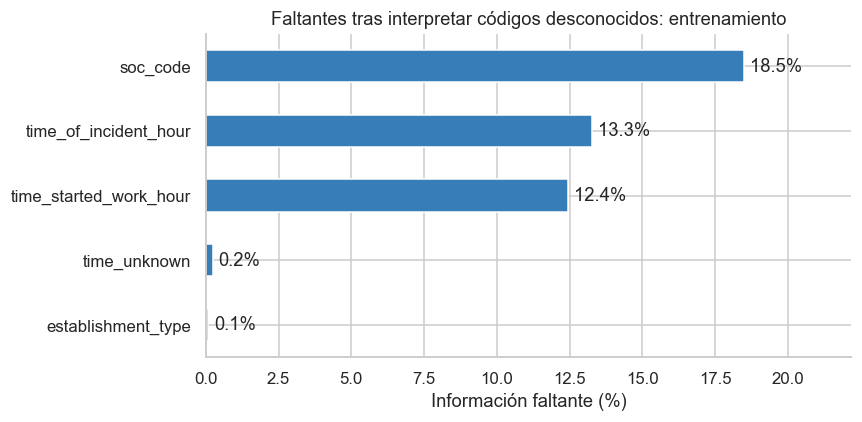

,state,naics_code,establishment_type,soc_code,type_of_incident,time_unknown,time_started_work_hour,time_of_incident_hour
Resultado,,,,,,,,
Fallecimiento (Death),0.000,0.000,0.000,16.038,0.000,0.000,12.264,10.377
Días de ausencia,0.000,0.000,0.059,17.522,0.000,0.297,13.987,17.176
Traslado / restricción,0.000,0.000,0.078,18.041,0.000,0.194,10.179,9.145
Otro caso registrable,0.000,0.000,0.120,19.891,0.000,0.236,12.746,12.636


In [6]:
eda.basic_overview(eda_view)
numeric_cols, categorical_cols = eda.get_column_types(feature_view)
display(eda.numeric_summary(feature_view, numeric_cols))
display(eda.categorical_summary(feature_view, categorical_cols))
predictor_missing = eda.missing_values_summary(feature_view)
display(predictor_missing)
fig, ax = plt.subplots(figsize=(8,4))
predictor_missing.missing_pct.sort_values().plot.barh(ax=ax, color='#377eb8')
ax.set(xlabel='Información faltante (%)', ylabel='', title='Faltantes tras interpretar códigos desconocidos: entrenamiento')
for p in ax.patches:
    ax.text(p.get_width()+0.2, p.get_y()+p.get_height()/2, f'{p.get_width():.1f}%', va='center')
ax.set_xlim(0, max(1,predictor_missing.missing_pct.max())*1.2)
plt.tight_layout(); plt.show()
missing_by_outcome = feature_view.isna().groupby(train.outcome).mean().mul(100).reindex(OUTCOMES.values())
display(missing_by_outcome)


Los faltantes no son necesariamente aleatorios: las horas desconocidas y las ocupaciones sin codificar pueden reflejar prácticas de reporte. Las diferencias entre resultados son asociaciones, no evidencia causal. Toda imputación aprendida debe permanecer dentro de Pipeline y ajustarse exclusivamente con entrenamiento.

**Hallazgos en entrenamiento:** la ocupación está sin codificar en 18,48 % de los casos; falta una hora utilizable del incidente en 13,26 % y de inicio del trabajo en 12,44 %. La falta de hora del incidente alcanza 17,18 % en casos con días de ausencia frente a 9,15 % en traslados/restricciones. Esto no demuestra un mecanismo MCAR, MAR o MNAR; persiste incertidumbre sobre el proceso de registro.


### 5.1 Análisis unidimensional formal de los predictores

Se resume cada predictor según su naturaleza. Los códigos NAICS, SOC, estado, tipo de establecimiento, tipo de incidente y `time_unknown` son **categóricos**, aunque algunos se almacenen como números. Las dos variables horarias se analizan como horas discretas de un ciclo de 24 horas; por esta razón, media, asimetría y normalidad tienen una interpretación limitada y no deben tratarse como si la hora 23 estuviera lejos de la hora 0.

Para las variables categóricas se reportan cardinalidad, categoría dominante y categorías raras (<1 %). Para las horas se muestran distribución y boxplot únicamente como descripción; no se eliminan valores por IQR porque 0–23 es el rango válido del reloj.


,Variable,Tipo,Cardinalidad,Faltantes (%),Categoría más frecuente,Frecuencia máxima (%),Categorías < 1 %,Casos en categorías < 1 % (%)
0,state,Categórica,56,0.000,CA,12.985,27.000,10.809
1,naics_code,Categórica,827,0.000,622110,17.473,813.000,38.817
2,establishment_type,Categórica,5,0.085,1,93.860,2.000,0.164
3,soc_code,Categórica,660,18.480,Desconocido,18.480,644.000,37.542
4,type_of_incident,Categórica,6,0.000,1,89.722,2.000,0.574
5,time_unknown,Categórica,3,0.246,0,86.719,1.000,0.246
6,time_started_work_hour,Hora discreta (0–23),24,12.438,7.0,16.462,NaN,NaN
7,time_of_incident_hour,Hora discreta (0–23),24,13.256,10.0,6.608,NaN,NaN


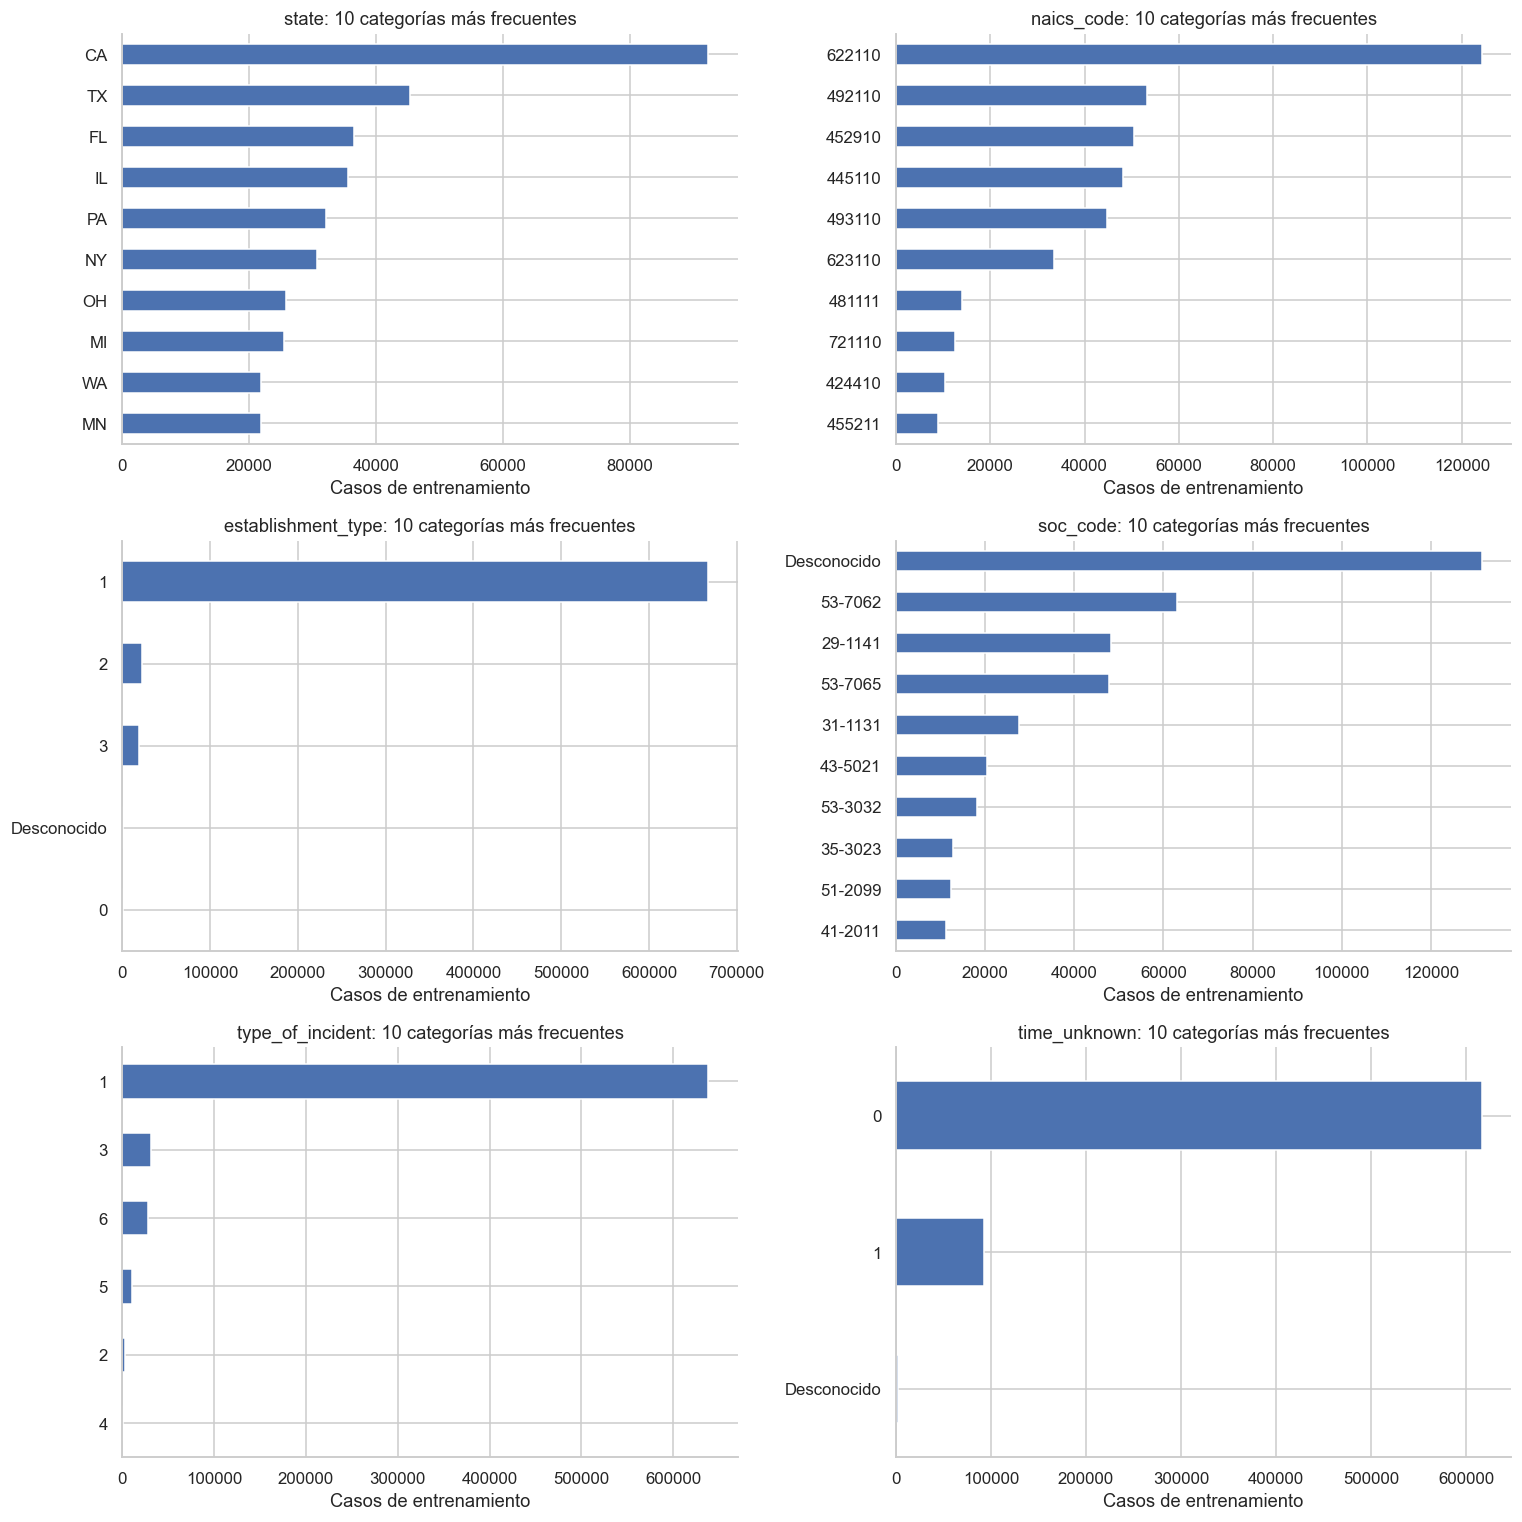

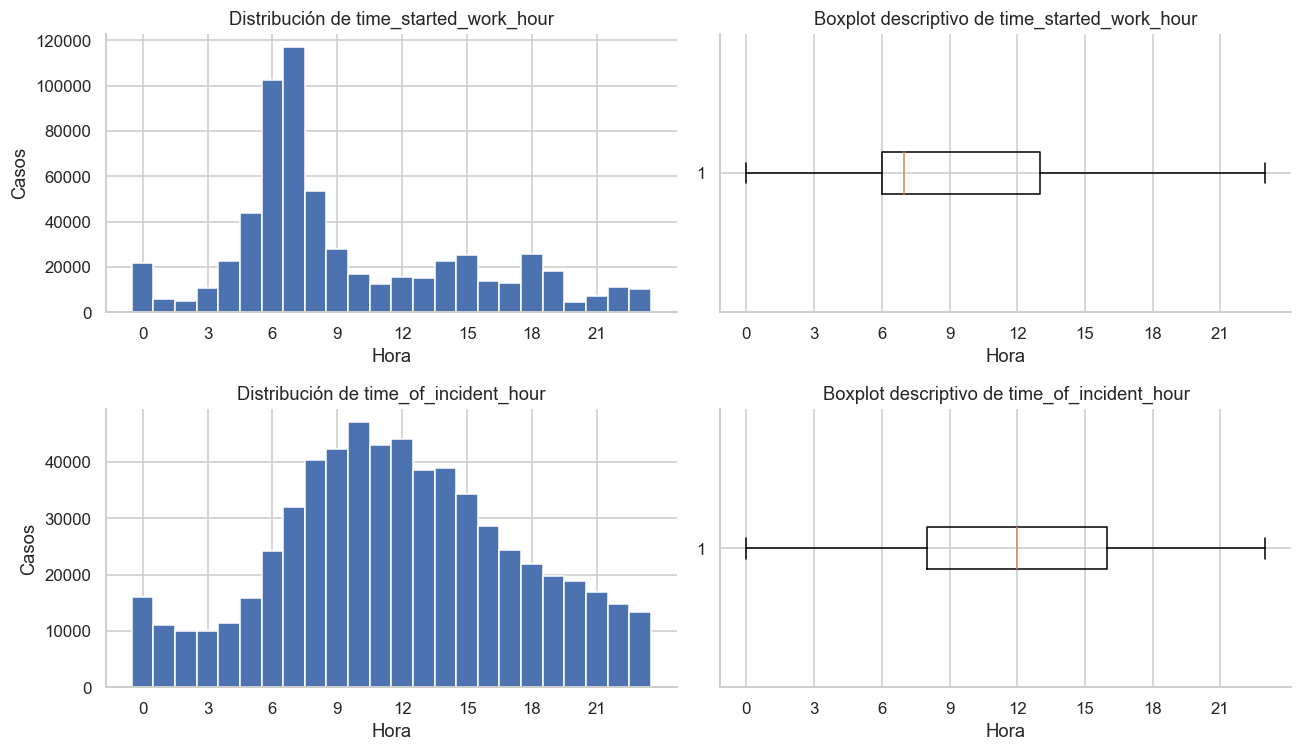

In [7]:
# Resumen unidimensional compacto de los ocho predictores
categorical_predictors = baseline['features'][:6]
hour_predictors = baseline['features'][6:]

univariate_rows = []
for c in categorical_predictors:
    s = feature_view[c].astype('object').fillna('Desconocido')
    counts = s.value_counts(dropna=False)
    rare_mask = (counts / len(s)) < 0.01
    univariate_rows.append({
        'Variable': c,
        'Tipo': 'Categórica',
        'Cardinalidad': int(s.nunique(dropna=False)),
        'Faltantes (%)': 100 * feature_view[c].isna().mean(),
        'Categoría más frecuente': str(counts.index[0]),
        'Frecuencia máxima (%)': 100 * counts.iloc[0] / len(s),
        'Categorías < 1 %': int(rare_mask.sum()),
        'Casos en categorías < 1 % (%)': 100 * counts.loc[rare_mask].sum() / len(s)
    })

for c in hour_predictors:
    s = pd.to_numeric(feature_view[c], errors='coerce')
    counts = s.value_counts(dropna=True)
    univariate_rows.append({
        'Variable': c,
        'Tipo': 'Hora discreta (0–23)',
        'Cardinalidad': int(s.nunique(dropna=True)),
        'Faltantes (%)': 100 * s.isna().mean(),
        'Categoría más frecuente': str(counts.index[0]) if len(counts) else 'NA',
        'Frecuencia máxima (%)': 100 * counts.iloc[0] / len(s) if len(counts) else np.nan,
        'Categorías < 1 %': np.nan,
        'Casos en categorías < 1 % (%)': np.nan
    })

display(pd.DataFrame(univariate_rows))

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, c in zip(axes.flat, categorical_predictors):
    s = feature_view[c].astype('object').fillna('Desconocido')
    counts = s.value_counts().head(10).iloc[::-1]
    counts.plot.barh(ax=ax)
    ax.set(title=f'{c}: 10 categorías más frecuentes',
           xlabel='Casos de entrenamiento', ylabel='')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for j, c in enumerate(hour_predictors):
    s = pd.to_numeric(feature_view[c], errors='coerce').dropna()
    axes[j, 0].hist(s, bins=np.arange(-0.5, 24.5, 1))
    axes[j, 0].set(title=f'Distribución de {c}', xlabel='Hora', ylabel='Casos',
                   xticks=range(0, 24, 3))
    axes[j, 1].boxplot(s, vert=False)
    axes[j, 1].set(title=f'Boxplot descriptivo de {c}', xlabel='Hora',
                   xticks=range(0, 24, 3))
plt.tight_layout()
plt.show()


### 5.2 Patrón y mecanismo de valores faltantes

El enunciado solicita distinguir MCAR, MAR y MNAR. Con estos datos observacionales no es posible demostrar el mecanismo de ausencia solo a partir del CSV. Sin embargo, se puede evaluar si la ausencia se relaciona con variables observadas.

La matriz siguiente visualiza una muestra aleatoria únicamente para mostrar **patrones de ausencia**; los porcentajes y cálculos continúan usando todo el entrenamiento. La concentración de faltantes por resultado y por variable contradice una lectura ingenua de “faltantes completamente al azar”. En consecuencia, el proyecto trata la imputación como parte del `Pipeline` y conserva explícitamente la incertidumbre sobre el mecanismo.


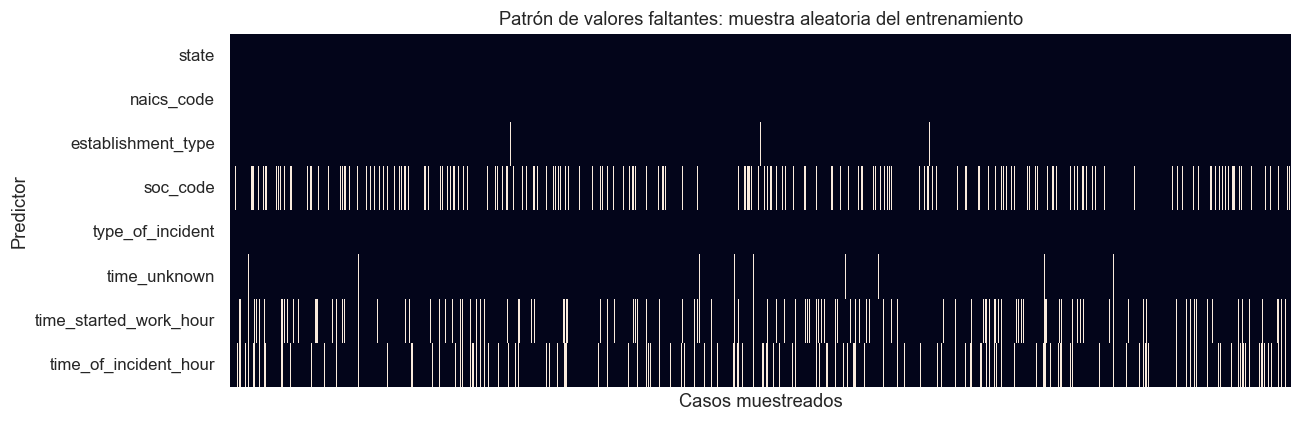

,state,naics_code,establishment_type,soc_code,type_of_incident,time_unknown,time_started_work_hour,time_of_incident_hour
Resultado,,,,,,,,
Fallecimiento (Death),0.000,0.000,0.000,16.038,0.000,0.000,12.264,10.377
Días de ausencia,0.000,0.000,0.059,17.522,0.000,0.297,13.987,17.176
Traslado / restricción,0.000,0.000,0.078,18.041,0.000,0.194,10.179,9.145
Otro caso registrable,0.000,0.000,0.120,19.891,0.000,0.236,12.746,12.636


In [8]:
missing_matrix = feature_view.isna()
missing_sample = missing_matrix.sample(n=min(3000, len(missing_matrix)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(missing_sample.T, cbar=False, yticklabels=True, xticklabels=False, ax=ax)
ax.set(title='Patrón de valores faltantes: muestra aleatoria del entrenamiento',
       xlabel='Casos muestreados', ylabel='Predictor')
plt.tight_layout()
plt.show()

display(
    missing_matrix.groupby(train.outcome)
    .mean()
    .mul(100)
    .reindex(OUTCOMES.values())
    .rename_axis('Resultado')
)


## 6. Distribución del resultado y del tipo de incidente


,Casos,Porcentaje
Fallecimiento (Death),212,0.030
Días de ausencia,259183,36.432
Traslado / restricción,210539,29.594
Otro caso registrable,241487,33.944


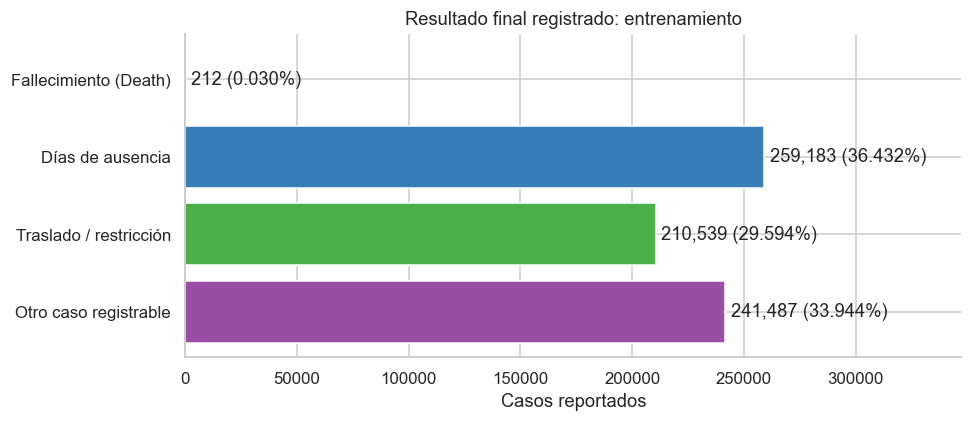

,Casos,Porcentaje
Lesión,638302,89.722
Afección respiratoria,31151,4.379
Otra enfermedad,27712,3.895
Pérdida auditiva,10172,1.430
Trastorno cutáneo,3418,0.480
Intoxicación,666,0.094


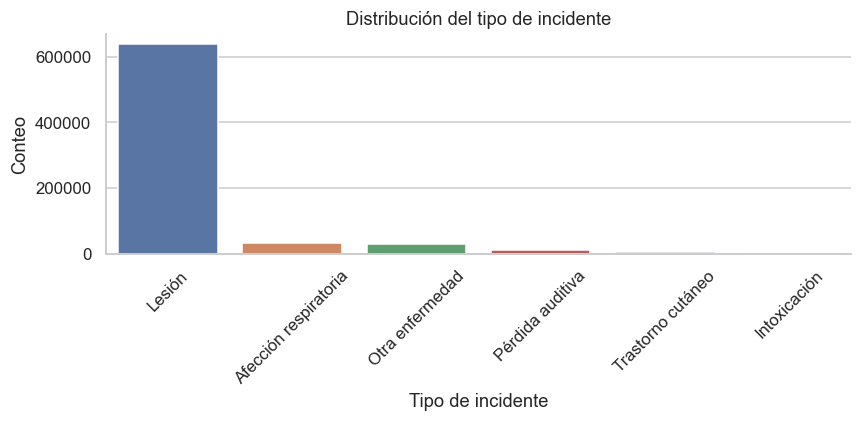

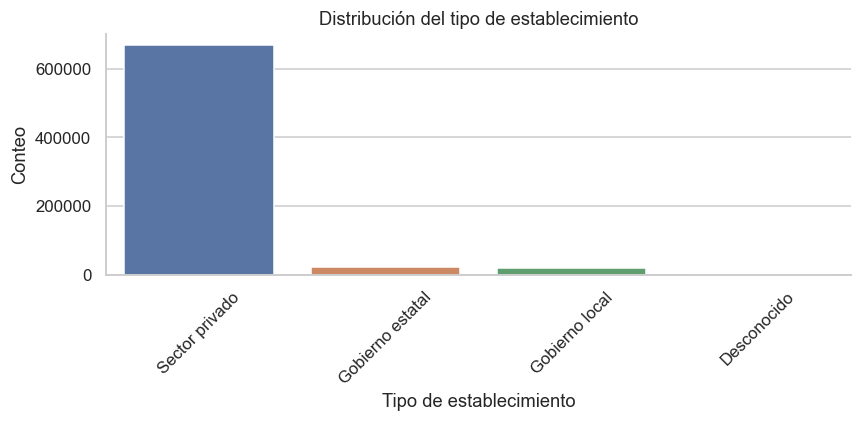

In [9]:
def count_table(series):
    t = series.fillna('Desconocido').value_counts().rename('cases').to_frame()
    t['percent'] = 100*t.cases/len(series)
    return t

target_counts = train.outcome.value_counts().reindex(OUTCOMES.values()).rename('cases').to_frame()
target_counts['percent'] = target_counts.cases/len(train)*100
display(target_counts)
fig, ax = plt.subplots(figsize=(9,4))
ax.barh(target_counts.index, target_counts.cases, color=['#b2182b','#377eb8','#4daf4a','#984ea3'])
for i, row in enumerate(target_counts.itertuples()):
    ax.text(row.cases+2500, i, f'{row.cases:,} ({row.percent:.3f}%)', va='center')
ax.set(xlabel='Casos reportados', ylabel='', title='Resultado final registrado: entrenamiento', xlim=(0,target_counts.cases.max()*1.34))
ax.invert_yaxis(); plt.tight_layout(); plt.show()
display(count_table(train.incident_type))
eda.plot_categorical_distributions(train, ['incident_type','establishment_type_label'], max_categories=10)


Death es una clase pequeña y sustantivamente distinta. La exactitud global puede ocultar un desempeño deficiente en ella. La exactitud balanceada (promedio de sensibilidad por clase), F1 macro y las métricas por clase deben complementar la exactitud. No se interpretan los códigos como una escala de gravedad de cuatro puntos ni se agrupan clases para mejorar las puntuaciones.


## 7. Industria, ocupación y distribución geográfica


,Casos,Porcentaje
Salud / asistencia social,196718,27.651
Transporte / almacenamiento,150184,21.110
Comercio minorista,136782,19.227
Manufactura,124810,17.544
Comercio mayorista,29307,4.120
Alojamiento / alimentación,18831,2.647
Administración pública,11044,1.552
Agricultura / silvicultura,10443,1.468
Arte / recreación,9246,1.300
Construcción,9122,1.282


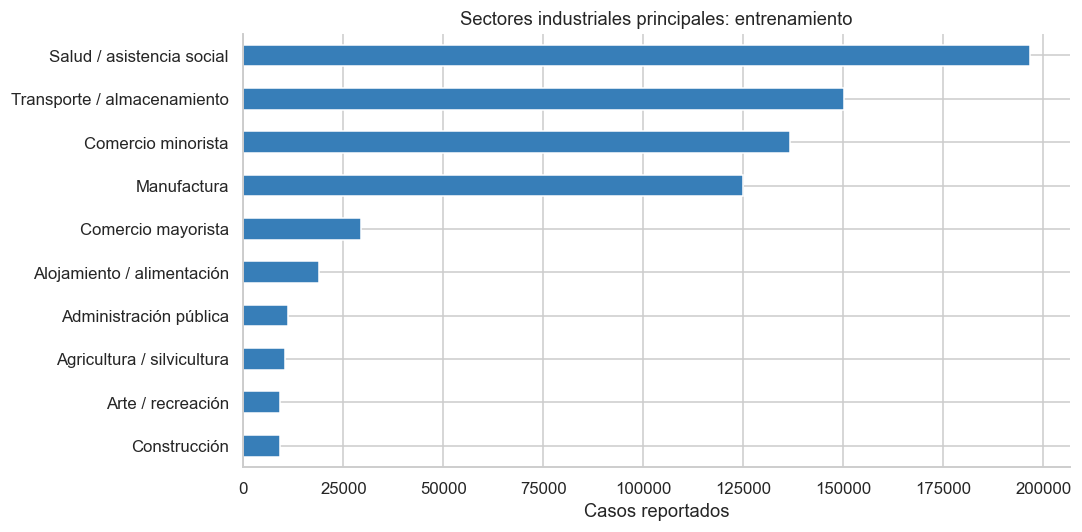

,Casos,Porcentaje
Sin codificar,131468,18.480
Trabajadores de carga y movimiento manual de materiales,62933,8.846
Profesionales de enfermería,48193,6.774
Reponedores y preparadores de pedidos,47805,6.720
Auxiliares de enfermería,27576,3.876
Mensajeros,20326,2.857
Conductores de camiones pesados y tractocamiones,18242,2.564
Otros ensambladores y fabricantes,14818,2.083
Trabajadores de comida rápida y mostrador,12755,1.793
Cajeros,11192,1.573


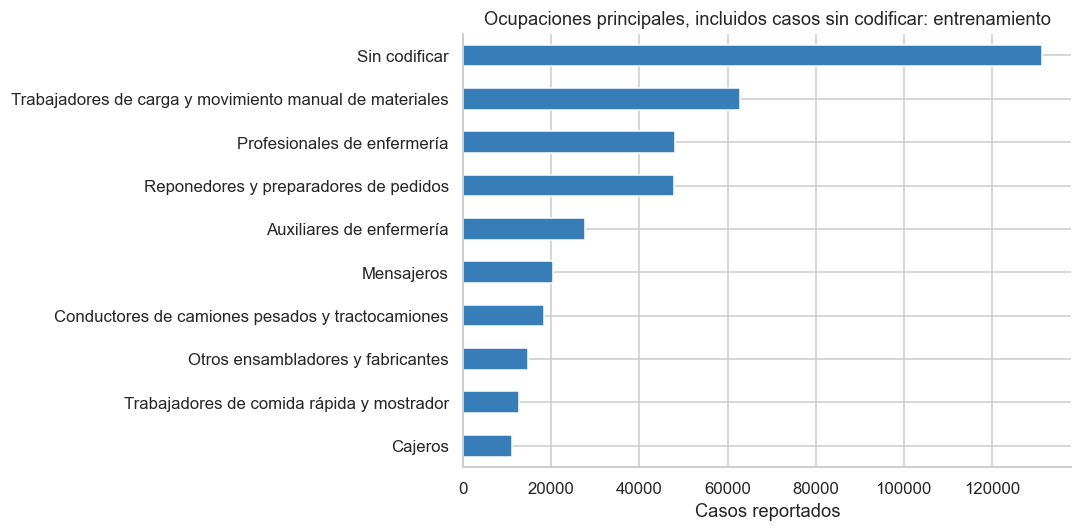

,Casos,Porcentaje
CA,92380,12.985
TX,45326,6.371
FL,36524,5.134
IL,35634,5.009
PA,32116,4.514
NY,30718,4.318
OH,25819,3.629
MI,25445,3.577
WA,21856,3.072
MN,21845,3.071


Códigos NAICS distintos: 827 | ocupaciones codificadas: 659 | códigos de estado/territorio: 56
Filas sin sector industrial reconocido: 85


In [10]:
def top_categories(series, title, n=10):
    table = count_table(series)
    display(table.head(n))
    shown = table.head(n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10,5))
    shown.cases.plot.barh(ax=ax, color='#377eb8')
    ax.set(title=title, xlabel='Casos reportados', ylabel='')
    plt.tight_layout(); plt.show()
    return table

industry_counts = top_categories(train.industry_sector, 'Sectores industriales principales: entrenamiento')
occupation_counts = top_categories(train.soc_description, 'Ocupaciones principales, incluidos casos sin codificar: entrenamiento')
state_counts = count_table(train.state)
display(state_counts.head(10))
print('Códigos NAICS distintos:', train.naics_code.nunique(), '| ocupaciones codificadas:', train.soc_code.nunique(), '| códigos de estado/territorio:', train.state.nunique())
print('Filas sin sector industrial reconocido:', int(train.industry_sector.eq('Código sin correspondencia').sum()))


Se muestran **proporciones de casos reportados**, no tasas de lesiones ni clasificaciones de riesgo industrial. El tamaño del establecimiento, las horas de exposición, los criterios de cobertura y las prácticas de reporte afectan los conteos. Industria y ocupación están relacionadas y pueden aportar información redundante. Las versiones de los códigos y los valores no reconocidos requieren una auditoría posterior del diccionario; no se les asigna un significado supuesto.


## 8. Relaciones entre predictores y resultado multiclase


incident_outcome,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
Salud / asistencia social,10,71417,33749,91542,196718
Transporte / almacenamiento,49,64471,62329,23335,150184
Comercio minorista,14,49519,33575,53674,136782
Manufactura,65,36902,46408,41435,124810
Comercio mayorista,12,12129,11613,5553,29307
Alojamiento / alimentación,9,6247,6245,6330,18831
Administración pública,14,4096,2190,4744,11044
Agricultura / silvicultura,18,3684,3168,3573,10443
Arte / recreación,2,2469,4181,2594,9246
Construcción,9,3037,2891,3185,9122


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable
Salud / asistencia social,0.005,36.304,17.156,46.535
Transporte / almacenamiento,0.033,42.928,41.502,15.538
Comercio minorista,0.010,36.203,24.546,39.241
Manufactura,0.052,29.567,37.183,33.198
Comercio mayorista,0.041,41.386,39.625,18.948
Alojamiento / alimentación,0.048,33.174,33.163,33.615
Administración pública,0.127,37.088,19.830,42.955
Agricultura / silvicultura,0.172,35.277,30.336,34.214
Arte / recreación,0.022,26.703,45.220,28.055
Construcción,0.099,33.293,31.693,34.916


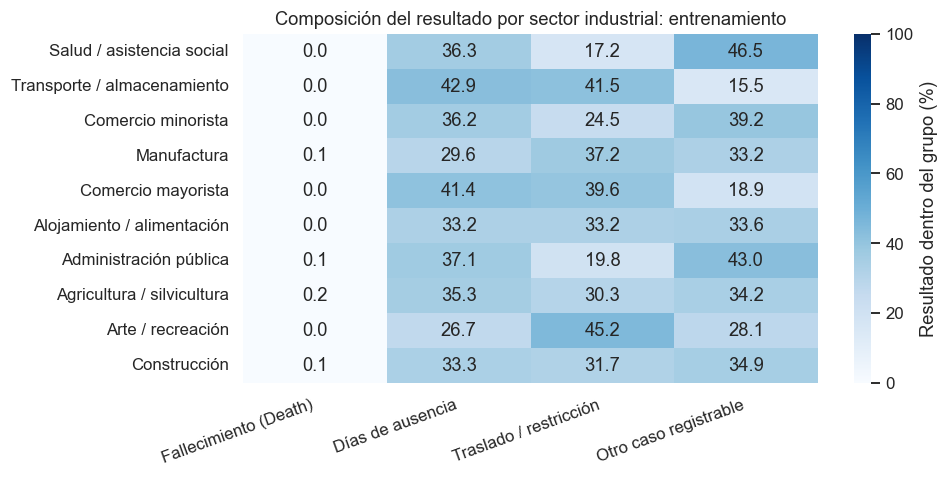

incident_outcome,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
incident_type,,,,,
Lesión,166,218373,201272,218491,638302
Trastorno cutáneo,0,1283,507,1628,3418
Afección respiratoria,6,28447,332,2366,31151
Intoxicación,0,215,124,327,666
Pérdida auditiva,1,1098,1037,8036,10172
Otra enfermedad,39,9767,7267,10639,27712


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable
incident_type,,,,
Lesión,0.026,34.212,31.532,34.230
Trastorno cutáneo,0.000,37.537,14.833,47.630
Afección respiratoria,0.019,91.320,1.066,7.595
Intoxicación,0.000,32.282,18.619,49.099
Pérdida auditiva,0.010,10.794,10.195,79.001
Otra enfermedad,0.141,35.245,26.223,38.391


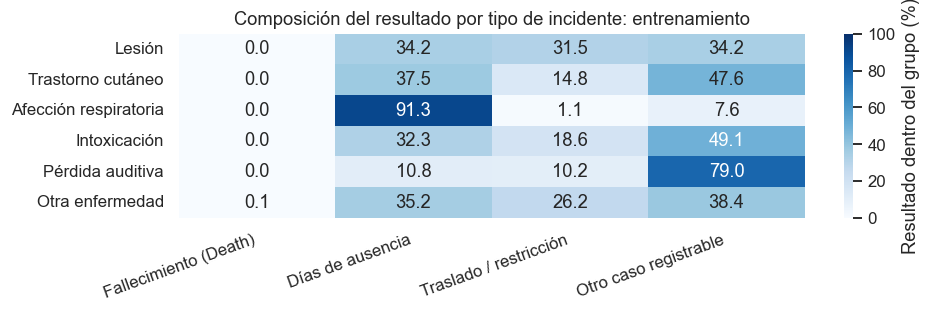

incident_outcome,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
Sin codificar,34,45415,37984,48035,131468
Trabajadores de carga y movimiento manual de materiales,8,22895,27086,12944,62933
Profesionales de enfermería,0,13221,6547,28425,48193
Reponedores y preparadores de pedidos,3,13616,24937,9249,47805
Auxiliares de enfermería,0,13998,6660,6918,27576
Mensajeros,5,10944,5847,3530,20326
Conductores de camiones pesados y tractocamiones,31,9307,5426,3478,18242
Otros ensambladores y fabricantes,2,4403,6235,4178,14818


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable
Sin codificar,0.026,34.545,28.892,36.537
Trabajadores de carga y movimiento manual de materiales,0.013,36.380,43.039,20.568
Profesionales de enfermería,0.000,27.433,13.585,58.982
Reponedores y preparadores de pedidos,0.006,28.482,52.164,19.347
Auxiliares de enfermería,0.000,50.762,24.151,25.087
Mensajeros,0.025,53.842,28.766,17.367
Conductores de camiones pesados y tractocamiones,0.170,51.020,29.745,19.066
Otros ensambladores y fabricantes,0.013,29.714,42.077,28.195


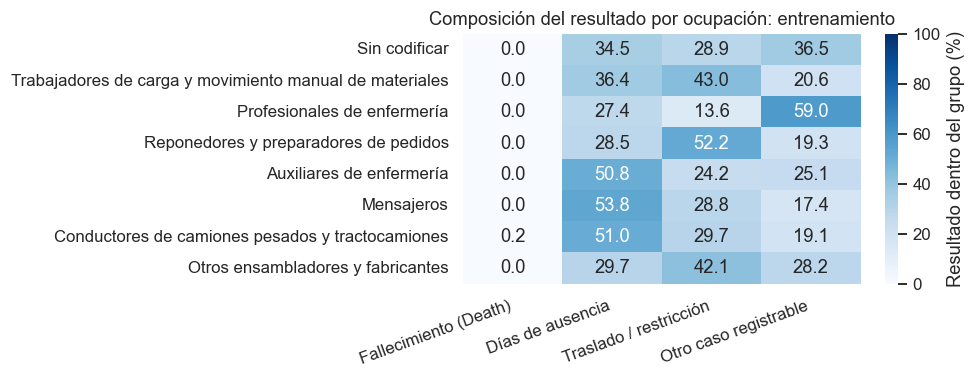

In [11]:
def outcome_comparison(column, title, levels=None):
    levels = levels if levels is not None else train[column].fillna('Desconocido').value_counts().head(10).index
    counts = pd.crosstab(train[column].fillna('Desconocido'), train[TARGET]).reindex(index=levels, columns=list(OUTCOMES), fill_value=0)
    proportions = counts.div(counts.sum(axis=1),axis=0)*100
    proportions.columns = [OUTCOMES[c] for c in proportions.columns]
    display(counts.rename(columns=OUTCOMES).assign(total_cases=counts.sum(axis=1)))
    display(proportions)
    fig, ax = plt.subplots(figsize=(9,max(3,len(levels)*0.45)))
    sns.heatmap(proportions, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, ax=ax, cbar_kws={'label':'Resultado dentro del grupo (%)'})
    ax.set(title=title, xlabel='', ylabel='')
    plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()
    return proportions

industry_outcomes = outcome_comparison('industry_sector', 'Composición del resultado por sector industrial: entrenamiento')
incident_outcomes = outcome_comparison('incident_type', 'Composición del resultado por tipo de incidente: entrenamiento', list(INCIDENTS.values()))
occupation_outcomes = outcome_comparison('soc_description', 'Composición del resultado por ocupación: entrenamiento', occupation_counts.head(8).index)


Los denominadores son los casos de cada grupo. Las tablas conservan los conteos de fallecimientos porque un mapa de porcentajes puede ocultar esta clase infrecuente. Las comparaciones son descriptivas y no están ajustadas por composición industria–ocupación, prácticas de los empleadores u otros factores. La dependencia dentro de establecimientos invalida una interpretación ingenua de pruebas basadas en filas independientes; por eso no se presentan esos valores p.

**Hallazgos en entrenamiento:** 91,32 % de los casos respiratorios corresponden a días de ausencia, mientras 79,00 % de los casos de pérdida auditiva son otros casos registrables. En lesiones, las tres clases no mortales están más próximas: 34,21 %, 31,53 % y 34,23 %. En enfermería profesional, 58,98 % corresponde a otros casos registrables; en reposición y preparación de pedidos, 52,16 % corresponde a traslado/restricción. Estas asociaciones respaldan la posibilidad de aprendizaje, pero combinan diferencias de casos y de reporte.


### 8.1 Asociación entre predictores y variable objetivo

Para los predictores categóricos se reporta **χ²** y **V de Cramér**. Debido a que hay cientos de miles de filas y dependencia dentro de establecimientos, los valores p pueden ser extremadamente pequeños incluso para asociaciones modestas; por ello, **V de Cramér es la medida principal de magnitud**. Los valores p se muestran como referencia descriptiva y se ajustan con Bonferroni.

También se reporta **información mutua normalizada (NMI)** como medida no lineal. Las horas se discretizan por hora del día para este cálculo. Para las dos variables horarias se añade Kruskal–Wallis y un tamaño de efecto aproximado ε². Ninguno de estos análisis implica causalidad.


,Predictor,Tipo de análisis,V de Cramér,NMI,p-valor χ²,Grados de libertad,p ajustado Bonferroni
1,naics_code,χ² / V de Cramér,0.235,0.032,0.000,2478,0.000
3,soc_code,χ² / V de Cramér,0.207,0.025,0.000,1977,0.000
4,type_of_incident,χ² / V de Cramér,0.157,0.049,0.000,15,0.000
0,state,χ² / V de Cramér,0.118,0.009,0.000,165,0.000
5,time_unknown,χ² / V de Cramér,0.068,0.006,0.000,6,0.000
2,establishment_type,χ² / V de Cramér,0.048,0.005,0.000,12,0.000


,Predictor,H de Kruskal–Wallis,p-valor,ε² aproximado,NMI (hora discretizada),Casos utilizables
0,time_started_work_hour,41.889,0.000,0.000,0.004,622932
1,time_of_incident_hour,270.053,0.000,0.000,0.003,617114


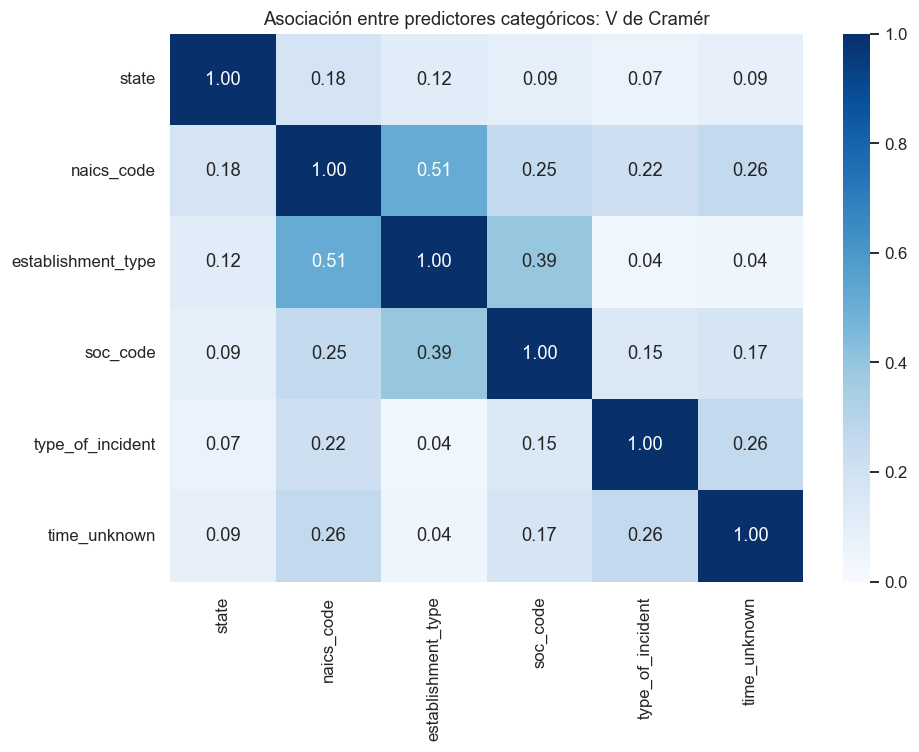

In [12]:
from scipy.stats import chi2_contingency, kruskal
from sklearn.metrics import normalized_mutual_info_score

def cramers_v_bias_corrected(x, y):
    table = pd.crosstab(
        pd.Series(x, copy=False).fillna('Desconocido').astype(str),
        pd.Series(y, copy=False).astype(str)
    )
    chi2, p, dof, _ = chi2_contingency(table, correction=False)
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    if n <= 1:
        return np.nan, p, dof
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    v = np.sqrt(phi2corr / denom) if denom > 0 else 0.0
    return float(v), float(p), int(dof)

association_rows = []
for c in categorical_predictors:
    s = feature_view[c].astype('object').fillna('Desconocido')
    v, p, dof = cramers_v_bias_corrected(s, train[TARGET])
    nmi = normalized_mutual_info_score(s.astype(str), train[TARGET].astype(str))
    association_rows.append({
        'Predictor': c,
        'Tipo de análisis': 'χ² / V de Cramér',
        'V de Cramér': v,
        'NMI': nmi,
        'p-valor χ²': p,
        'Grados de libertad': dof
    })

association_df = pd.DataFrame(association_rows)
association_df['p ajustado Bonferroni'] = np.minimum(
    association_df['p-valor χ²'] * len(association_df), 1.0
)
display(association_df.sort_values('V de Cramér', ascending=False))

hour_rows = []
for c in hour_predictors:
    s = pd.to_numeric(feature_view[c], errors='coerce')
    groups = [s.loc[train[TARGET].eq(label)].dropna().to_numpy() for label in sorted(OUTCOMES)]
    H, p = kruskal(*groups)
    n = sum(len(g) for g in groups)
    k = len(groups)
    epsilon2 = max(0.0, (H - k + 1) / (n - k)) if n > k else np.nan
    hour_as_category = s.round().astype('Int64').astype(str).replace('<NA>', 'Desconocido')
    nmi = normalized_mutual_info_score(hour_as_category, train[TARGET].astype(str))
    hour_rows.append({
        'Predictor': c,
        'H de Kruskal–Wallis': H,
        'p-valor': p,
        'ε² aproximado': epsilon2,
        'NMI (hora discretizada)': nmi,
        'Casos utilizables': n
    })
display(pd.DataFrame(hour_rows))

pair_vars = list(categorical_predictors)
v_matrix = pd.DataFrame(np.eye(len(pair_vars)), index=pair_vars, columns=pair_vars)
for i, a in enumerate(pair_vars):
    for j in range(i + 1, len(pair_vars)):
        b = pair_vars[j]
        v, _, _ = cramers_v_bias_corrected(
            feature_view[a].astype('object').fillna('Desconocido'),
            feature_view[b].astype('object').fillna('Desconocido')
        )
        v_matrix.loc[a, b] = v_matrix.loc[b, a] = v

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(v_matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='Blues', ax=ax)
ax.set_title('Asociación entre predictores categóricos: V de Cramér')
plt.tight_layout()
plt.show()


### 8.2 Estructura multivariada exploratoria

PCA sobre los códigos NAICS, SOC o estado **no es apropiado**, porque sus números son etiquetas nominales y no magnitudes. Para obtener una visualización multivariada compatible con la representación del modelo se aplica **TruncatedSVD** a una codificación one-hot de una muestra del entrenamiento. Se incluyen todos los fallecimientos y una muestra aleatoria de las demás clases únicamente para hacer visible la clase rara; por tanto, la figura **no representa prevalencias poblacionales** y no se utiliza para seleccionar variables ni para entrenar el modelo.

No se aplica distancia de Mahalanobis sobre los códigos nominales ni se eliminan “outliers multivariados” a partir de distancias arbitrarias en una representación one-hot. Los valores imposibles e inconsistentes se auditan directamente en sus campos originales.


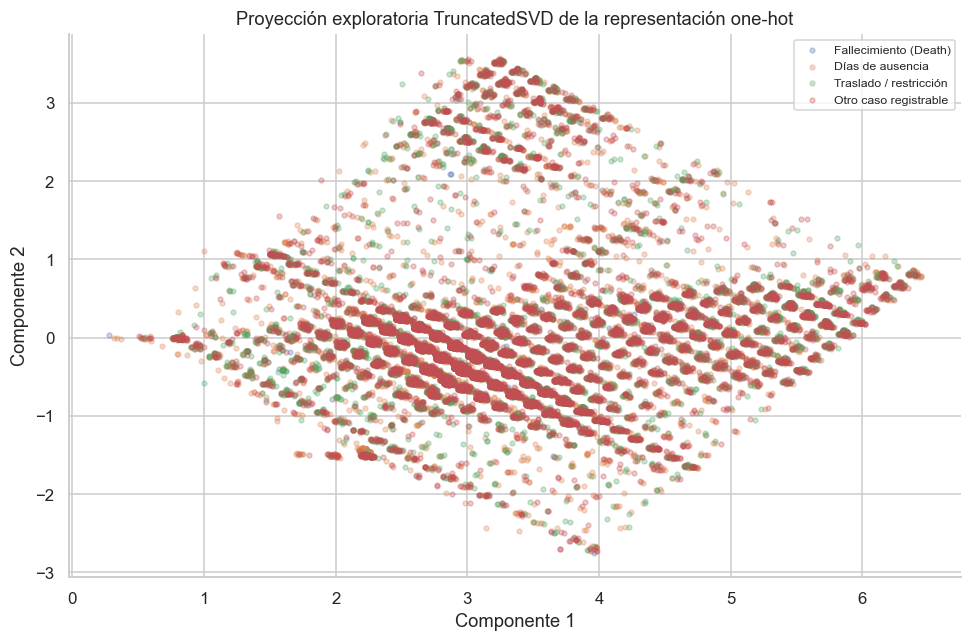

Varianza explicada por los dos componentes: 33.26%
Casos visualizados: 30212 | Death: 212 | otras clases muestreadas: 30000


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

death_rows = train.loc[train[TARGET].eq(1)]
nondeath_rows = train.loc[train[TARGET].ne(1)]
nondeath_sample = nondeath_rows.sample(
    n=min(30000, len(nondeath_rows)),
    random_state=42
)
vis = pd.concat([death_rows, nondeath_sample], axis=0)

cat_vis = list(categorical_predictors)
num_vis = list(hour_predictors)
pre_vis = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_vis),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler(with_mean=False))
        ]), num_vis)
    ],
    sparse_threshold=1.0
)

X_vis = pre_vis.fit_transform(vis[baseline['features']])
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X_vis)

fig, ax = plt.subplots(figsize=(9, 6))
for label in sorted(OUTCOMES):
    mask = vis[TARGET].to_numpy() == label
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.30, label=OUTCOMES[label])
ax.set(
    title='Proyección exploratoria TruncatedSVD de la representación one-hot',
    xlabel='Componente 1',
    ylabel='Componente 2'
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Varianza explicada por los dos componentes:',
      f'{100 * svd.explained_variance_ratio_.sum():.2f}%')
print('Casos visualizados:', len(vis),
      '| Death:', int(vis[TARGET].eq(1).sum()),
      '| otras clases muestreadas:', int(vis[TARGET].ne(1).sum()))


## 9. Patrones temporales y precisión del registro


,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total de casos
incident_date,,,,,
1,16,24451,17190,18819,60476
2,16,21749,16242,18250,56257
3,15,22546,18279,20468,61308
4,17,19882,16694,18815,55408
5,18,20743,17948,20602,59311
6,13,20383,18468,20843,59707
7,18,21717,18602,21121,61458
8,27,23894,19486,22522,65929
9,21,21677,17364,20742,59804


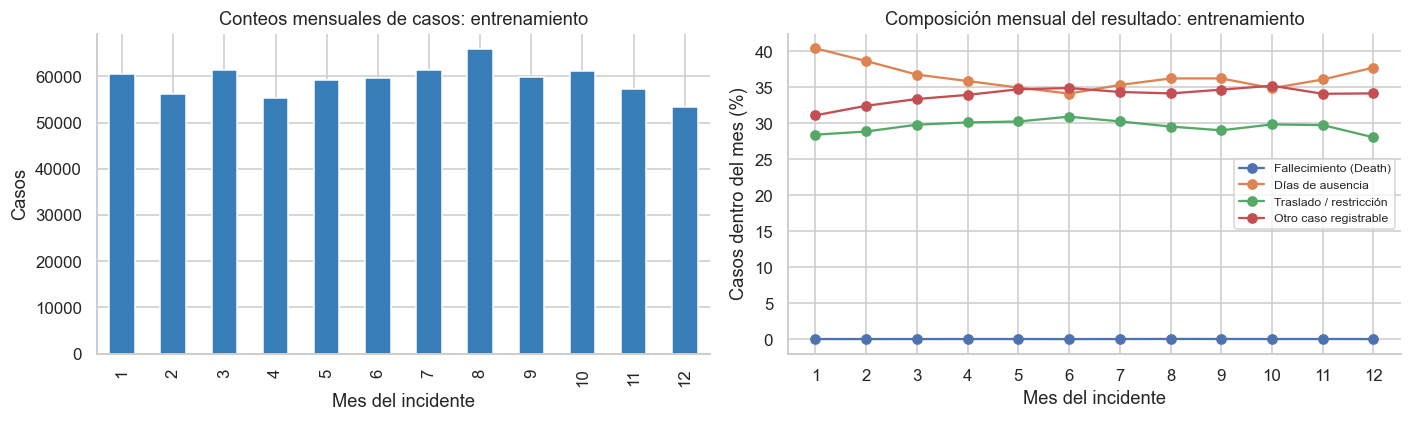

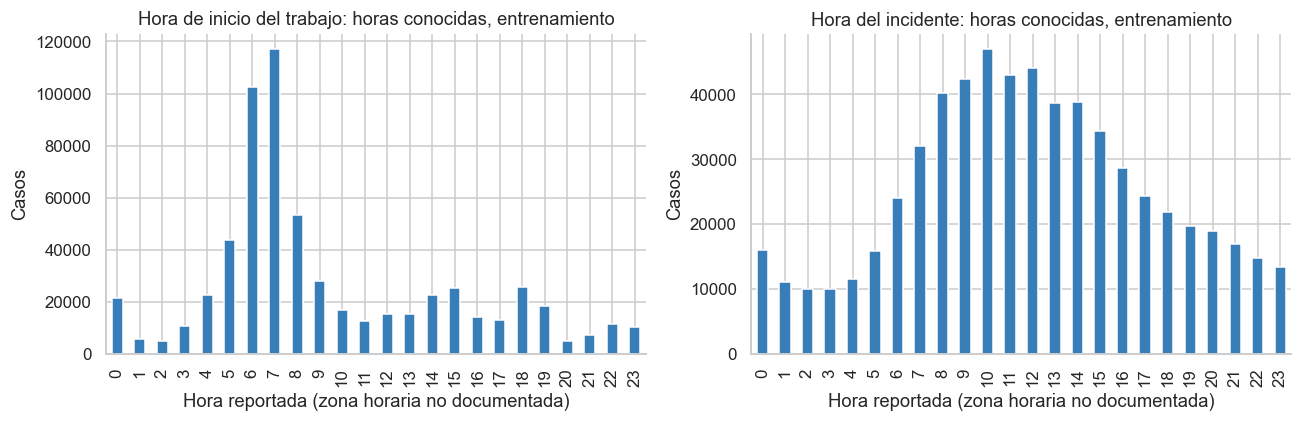

,Registros originales presentes,Minutos iguales a 00,Hora desconocida o no utilizable
time_started_work,622932,397542,88489
time_of_incident,623225,214258,94307


In [14]:
monthly = pd.crosstab(train.incident_date.dt.month, train[TARGET]).reindex(index=range(1,13), columns=list(OUTCOMES), fill_value=0)
monthly.columns = list(OUTCOMES.values())
display(monthly.assign(total_cases=monthly.sum(axis=1)))
fig, axes = plt.subplots(1,2,figsize=(13,4))
monthly.sum(axis=1).plot.bar(ax=axes[0],color='#377eb8')
axes[0].set(title='Conteos mensuales de casos: entrenamiento',xlabel='Mes del incidente',ylabel='Casos')
monthly.div(monthly.sum(axis=1),axis=0).mul(100).plot(ax=axes[1],marker='o')
axes[1].set(title='Composición mensual del resultado: entrenamiento',xlabel='Mes del incidente',ylabel='Casos dentro del mes (%)',xticks=range(1,13))
axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax,c,label in zip(axes,['time_started_work_hour','time_of_incident_hour'],['Hora de inicio del trabajo','Hora del incidente']):
    counts = train[c].value_counts().reindex(range(24),fill_value=0)
    counts.plot.bar(ax=ax,color='#377eb8')
    ax.set(title=label+': horas conocidas, entrenamiento',xlabel='Hora reportada (zona horaria no documentada)',ylabel='Casos')
plt.tight_layout(); plt.show()
time_audit = {}
for c in ['time_started_work','time_of_incident']:
    raw = train[c].dropna()
    time_audit[c] = {'nonmissing_raw':len(raw), 'minutes_equal_00':int(raw.str.match(r'^\d{1,2}:00:').sum()),
                     'unusable_or_unknown_hour':int(train[c+'_hour'].isna().sum())}
display(pd.DataFrame(time_audit).T)


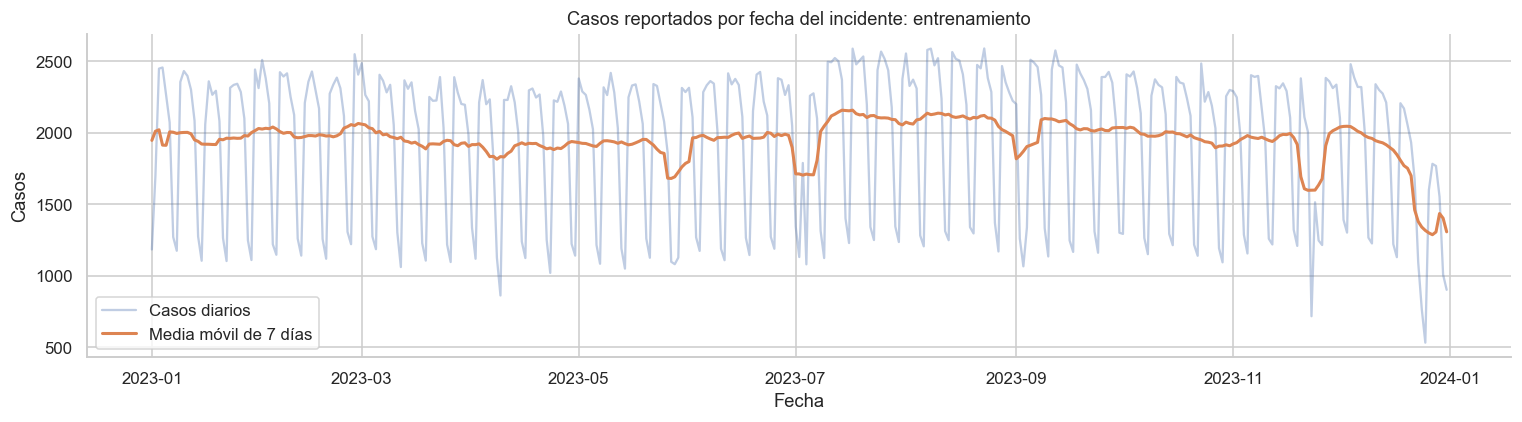

,Fallecimiento (Death),Días de ausencia,Traslado / restricción,Otro caso registrable,Total
Lunes,46,43172,35667,38805,117690
Martes,40,43283,36865,40776,120964
Miércoles,32,43433,36767,41507,121739
Jueves,34,41581,35459,40194,117268
Viernes,29,38614,31241,37733,107617
Sábado,21,25571,17894,22187,65673
Domingo,10,23529,16646,20285,60470


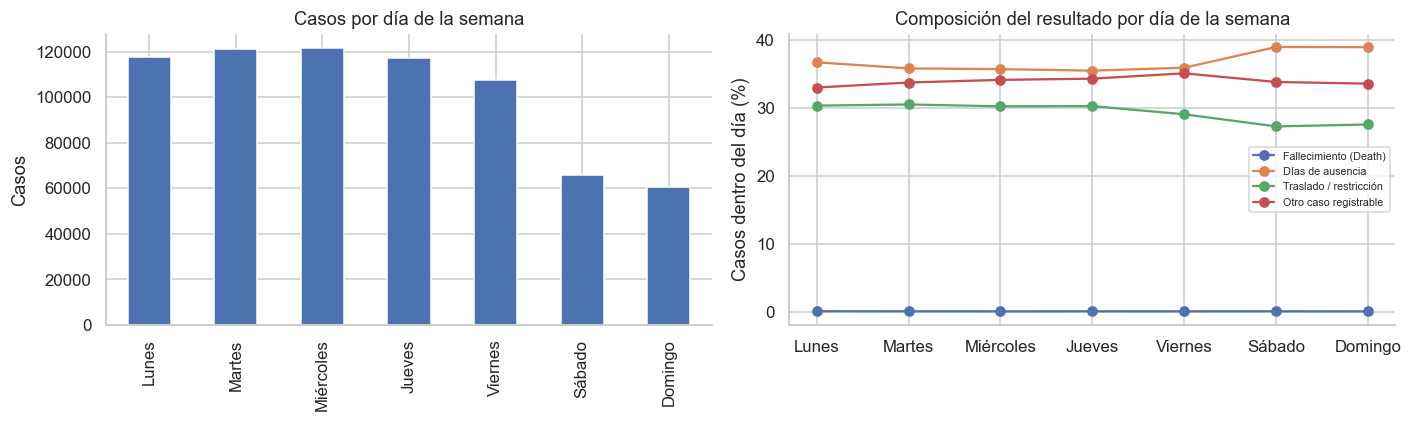

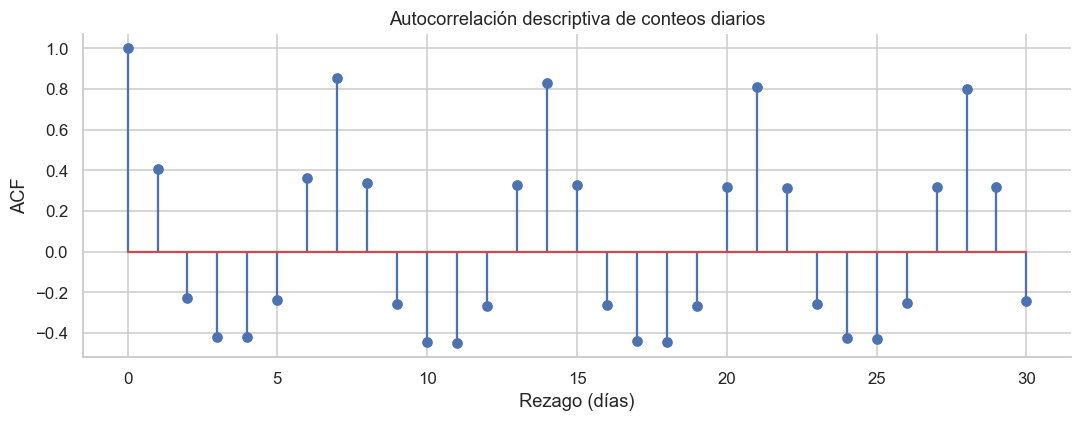

statsmodels no está disponible en ml_env; no se instala un paquete nuevo para esta entrega.


In [15]:
calendar = pd.date_range('2023-01-01', '2023-12-31', freq='D')
daily_cases = (
    train.groupby(train.incident_date.dt.normalize())
    .size()
    .reindex(calendar, fill_value=0)
)
rolling7 = daily_cases.rolling(7, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_cases.index, daily_cases.values, alpha=0.35, label='Casos diarios')
ax.plot(rolling7.index, rolling7.values, linewidth=2, label='Media móvil de 7 días')
ax.set(title='Casos reportados por fecha del incidente: entrenamiento',
       xlabel='Fecha', ylabel='Casos')
ax.legend()
plt.tight_layout()
plt.show()

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_es = {
    'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'
}
weekday = pd.crosstab(train.incident_date.dt.day_name(), train[TARGET]).reindex(weekday_order)
weekday.columns = [OUTCOMES[c] for c in weekday.columns]
weekday.index = [weekday_es[d] for d in weekday.index]
display(weekday.assign(Total=weekday.sum(axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
weekday.sum(axis=1).plot.bar(ax=axes[0])
axes[0].set(title='Casos por día de la semana', xlabel='', ylabel='Casos')
weekday.div(weekday.sum(axis=1), axis=0).mul(100).plot(ax=axes[1], marker='o')
axes[1].set(title='Composición del resultado por día de la semana',
            xlabel='', ylabel='Casos dentro del día (%)')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

x = daily_cases.to_numpy(dtype=float)
x_centered = x - x.mean()
denom = np.dot(x_centered, x_centered)
max_lag = 30
acf_vals = [1.0]
for lag in range(1, max_lag + 1):
    acf_vals.append(
        np.dot(x_centered[:-lag], x_centered[lag:]) / denom if denom else np.nan
    )

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(max_lag + 1), acf_vals)
ax.set(title='Autocorrelación descriptiva de conteos diarios',
       xlabel='Rezago (días)', ylabel='ACF')
plt.tight_layout()
plt.show()

try:
    from statsmodels.tsa.seasonal import STL
    from statsmodels.tsa.stattools import adfuller, kpss

    stl = STL(daily_cases.astype(float), period=7, robust=True).fit()
    fig = stl.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle('Descomposición STL de conteos diarios (periodicidad semanal)', y=1.01)
    plt.tight_layout()
    plt.show()

    adf_stat, adf_p, *_ = adfuller(daily_cases.astype(float), autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(daily_cases.astype(float), regression='c', nlags='auto')
    display(pd.DataFrame({
        'Prueba': ['ADF', 'KPSS'],
        'Estadístico': [adf_stat, kpss_stat],
        'p-valor': [adf_p, kpss_p],
        'Hipótesis nula': ['raíz unitaria / no estacionaria', 'estacionaria']
    }))
except ImportError:
    print('statsmodels no está disponible en ml_env; no se instala un paquete nuevo para esta entrega.')
except Exception as exc:
    print('STL/ADF/KPSS no pudieron calcularse de forma fiable:', repr(exc))


**Interpretación del componente temporal.** La fecha describe cuándo ocurrió cada evento, pero las filas no constituyen una serie temporal regular de una única entidad: son casos administrativos provenientes de miles de establecimientos. Por eso, STL, ADF/KPSS y ACF sobre el **conteo agregado diario** se interpretan únicamente como diagnóstico descriptivo del flujo de casos, no como evidencia de que el target individual deba modelarse con forecasting.

La pregunta principal del proyecto es la generalización a establecimientos no vistos, por lo que la evaluación principal conserva grupos por establecimiento. Con un solo año no se puede demostrar generalización a años futuros. Una evaluación prospectiva por periodos deberá plantearse como análisis complementario cuando se disponga de más de un periodo comparable.


Un solo año no permite establecer estacionalidad reproducible ni generalización a años futuros. Los conteos mensuales no tienen un denominador de horas de exposición. La distribución horaria refleja tanto exposición como precisión del reporte. Medianoche puede ser una hora válida o un valor por defecto; la zona horaria no está documentada en estos campos. Se enmascaran las horas declaradas desconocidas, pero el archivo no resuelve todos los redondeos o valores por defecto. No se infiere la duración del turno al cruzar medianoche.

**Alcance de validación:** por instrucción del proyecto se mantiene la evaluación en establecimientos no vistos, dentro del mismo periodo, y no se afirma capacidad de pronóstico temporal. La sección 2.6 del enunciado exige análisis y partición cronológicos cuando hay fechas u horas. Esa diferencia debe explicarse al docente; este entregable no afirma haber satisfecho la validación de años o periodos futuros ni sustituye el diseño agrupado por uno cronológico.


## 10. Agrupación por establecimiento y medidas descriptivas del lugar de trabajo


,Casos reportados
Conteo,"73,004.000"
Media,9.745
Desviación estándar,29.930
Mínimo,1.000
50%,4.000
90%,19.000
95%,31.000
99%,97.000
Máximo,"2,948.000"


Los 100 establecimientos con más casos concentran 7.49% del entrenamiento.


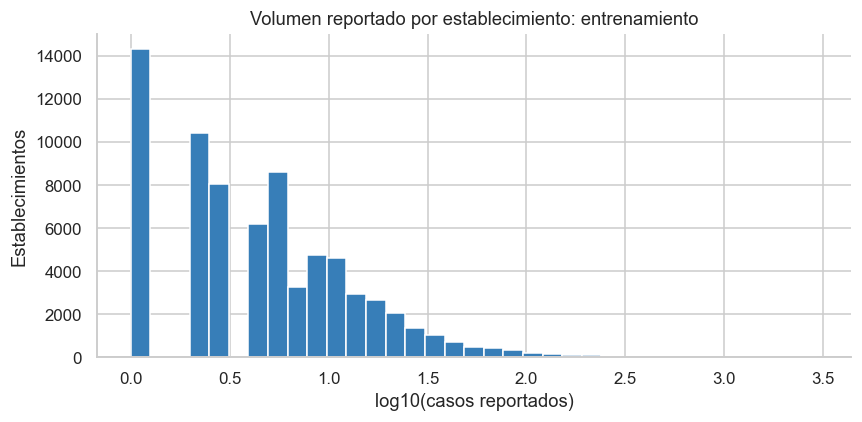

,Conteo,Media,Desviación estándar,Mínimo,50%,90%,99%,Máximo
Casos,"73,004.000",9.745,29.930,1.000,4.000,19.000,97.000,"2,948.000"
Resultados distintos,"73,004.000",1.939,0.800,1.000,2.000,3.000,3.000,4.000
Proporción del resultado más frecuente,"73,004.000",0.748,0.217,0.250,0.727,1.000,1.000,1.000


,Establecimientos con valores inconsistentes
annual_average_employees,0
total_hours_worked,0
size,0


,Conteo,Media,Desviación estándar,Mínimo,25%,50%,75%,Máximo
annual_average_employees,"73,004.000","2,927.288","640,685.218",0.000,57.000,118.000,210.000,"172,307,584.000"
total_hours_worked,"73,004.000","657,873.193","19,553,982.193",0.000,"93,242.000","187,096.000","347,012.000","2,960,260,000.000"


,Conteo
Establecimientos con empleados <= 0,14
Establecimientos con horas <= 0,28


In [16]:
cases_per_establishment = train.groupby(GROUP).size().rename('reported_cases')
display(cases_per_establishment.describe(percentiles=[.5,.9,.95,.99]).to_frame())
largest_share = 100*cases_per_establishment.nlargest(100).sum()/len(train)
print(f'Los 100 establecimientos con más casos concentran {largest_share:.2f}% del entrenamiento.')
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(np.log10(cases_per_establishment),bins=35,color='#377eb8')
ax.set(title='Volumen reportado por establecimiento: entrenamiento',xlabel='log10(casos reportados)',ylabel='Establecimientos')
plt.tight_layout(); plt.show()
establishment_outcomes = pd.crosstab(train[GROUP],train[TARGET]).reindex(columns=list(OUTCOMES),fill_value=0)
cluster_summary = pd.DataFrame({'cases':establishment_outcomes.sum(axis=1),
                                'distinct_outcomes':establishment_outcomes.gt(0).sum(axis=1),
                                'largest_outcome_share':establishment_outcomes.max(axis=1)/establishment_outcomes.sum(axis=1)})
display(cluster_summary.describe(percentiles=[.5,.9,.99]).T)
establishment_fields = ['annual_average_employees','total_hours_worked','size']
inconsistent = train.groupby(GROUP)[establishment_fields].nunique(dropna=False).gt(1).sum()
display(inconsistent.rename('establishments_with_inconsistent_values').to_frame())
establishments = train.drop_duplicates(GROUP).set_index(GROUP)
display(eda.numeric_summary(establishments,['annual_average_employees','total_hours_worked']))
display(pd.Series({
    'Establecimientos con empleados <= 0':int(establishments.annual_average_employees.le(0).sum()),
    'Establecimientos con horas <= 0':int(establishments.total_hours_worked.le(0).sum())
},name='count').to_frame())


Los totales anuales se resumen una sola vez por establecimiento; no se suman las copias presentes en cada caso. Si existieran inconsistencias internas, el uso del primer registro requeriría revisión. Estas variables siguen excluidas como predictores porque pueden incorporar información posterior al incidente. No hay identificador de trabajador para detectar casos recurrentes de una misma persona. Establecimientos distintos también pueden pertenecer a una misma empresa.

**Hallazgos en entrenamiento:** la mediana es 4 casos por establecimiento, el máximo 2.948 y los 100 establecimientos con más casos concentran 7,49 %. Los resúmenes anuales coinciden dentro de cada establecimiento, pero no siempre son plausibles: el máximo de empleados promedio reportados es 172.307.584; 14 establecimientos registran cero empleados y 28, cero horas. El extremo de personal requiere verificación de fuente; no se corrige ni se considera plausible aquí. La mediana es más informativa que la media fuertemente distorsionada. Estas variables permanecen excluidas.


## 11. Auditoría de claves de caso y coherencia del resultado: solo entrenamiento


In [17]:
reused = train.duplicated([GROUP,'case_number'],keep=False)
reused_groups = train.loc[reused].groupby([GROUP,'case_number'],dropna=False)
death_dates = pd.to_datetime(train.date_of_death,format='%m/%d/%Y',errors='coerce')
checks = {
    'Números de caso faltantes':int(train.case_number.isna().sum()),
    'Identificadores ITA duplicados':int(train.id.duplicated().sum()),
    'Filas con clave establecimiento/número de caso repetida':int(reused.sum()),
    'Claves repetidas con varias fechas de incidente':int(reused_groups.incident_date.nunique().gt(1).sum()),
    'Claves repetidas con varios resultados':int(reused_groups[TARGET].nunique().gt(1).sum()),
    'Resultado de ausencia con días de ausencia <= 0':int((train[TARGET].eq(2)&train.dafw_num_away.le(0)).sum()),
    'Resultado de traslado/restricción con días de restricción <= 0':int((train[TARGET].eq(3)&train.djtr_num_tr.le(0)).sum()),
    'Otro caso registrable con días de ausencia/restricción positivos':int((train[TARGET].eq(4)&(train.dafw_num_away.gt(0)|train.djtr_num_tr.gt(0))).sum()),
    'Casos no mortales con fecha de fallecimiento':int((train[TARGET].ne(1)&train.date_of_death.notna()).sum()),
    'Fallecimientos sin fecha de fallecimiento':int((train[TARGET].eq(1)&train.date_of_death.isna()).sum()),
    'Fecha de fallecimiento anterior al incidente':int((death_dates<train.incident_date).sum()),
    'Fechas de fallecimiento presentes no interpretables':int((train.date_of_death.notna()&death_dates.isna()).sum()),
    'Días de ausencia/restricción negativos':int((train.dafw_num_away.lt(0)|train.djtr_num_tr.lt(0)).sum())
}
display(pd.Series(checks,name='cases_or_groups').to_frame())
leakage_audit = pd.crosstab(train.outcome, [train.dafw_num_away.gt(0), train.djtr_num_tr.gt(0)])
leakage_audit.columns.names = ['Días de ausencia positivos','Días de restricción positivos']
display(leakage_audit.reindex(OUTCOMES.values()))


,Casos o grupos
Números de caso faltantes,9
Identificadores ITA duplicados,0
Filas con clave establecimiento/número de caso repetida,64965
Claves repetidas con varias fechas de incidente,8687
Claves repetidas con varios resultados,6179
Resultado de ausencia con días de ausencia <= 0,1531
Resultado de traslado/restricción con días de restricción <= 0,1247
Otro caso registrable con días de ausencia/restricción positivos,1544
Casos no mortales con fecha de fallecimiento,0
Fallecimientos sin fecha de fallecimiento,0


Días de ausencia positivos      False           True        
Días de restricción positivos   False   True    False  True 
Resultado                                                   
Fallecimiento (Death)             201       1      10      0
Días de ausencia                  958     573  185302  72350
Traslado / restricción           1089  208640     158    652
Otro caso registrable          239943    1004     416    124

El número de caso del empleador no constituye una clave fiable para deduplicar: puede repetirse en fechas y resultados distintos. Las coincidencias tras eliminar identificadores administrativos son sospechosas, pero también pueden surgir por anonimización o descripciones generales idénticas. No se deduplican ni se cambian etiquetas silenciosamente. Las discrepancias entre resultado y días son alertas de calidad, no autorización para reconstruir el objetivo usando información filtrada. La agrupación evita que duplicados del mismo establecimiento crucen la partición, aunque no elimina su efecto de ponderación.

**Hallazgos en entrenamiento:** 1.531 casos con días de ausencia registran cero días; 1.247 casos de traslado/restricción registran cero días de restricción; 1.544 casos clasificados como otros registrables tienen días positivos de recuperación. No se puede establecer cuál campo está equivocado. Las comprobaciones de presencia y cronología de fecha de fallecimiento no detectaron discrepancias. Se preserva el objetivo suministrado hasta justificar una política explícita de limpieza.


## 12. Referencia preliminar de viabilidad: resultados conservados

La evaluación preliminar utilizó imputación constante y codificación one-hot aprendidas solo en entrenamiento, seguidas de `LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)`. Se conserva su advertencia y sus resultados como registro histórico; **no son el ajuste numéricamente corregido** presentado después. No se vuelve a ejecutar este modelo histórico.


In [18]:
display(pd.DataFrame({
    'logistic_regression':[baseline['balanced_accuracy'],baseline['accuracy'],baseline['macro_f1']],
    'constant_reference':[baseline['constant_classifier_balanced_accuracy_reference'],baseline['majority_accuracy_reference'],np.nan]
},index=['Exactitud balanceada','Exactitud','F1 macro']))
display(pd.DataFrame(baseline['confusion_matrix'],index=[f'Observado: {OUTCOMES[c]}' for c in baseline['confusion_matrix_labels']],
                     columns=[f'Predicho: {OUTCOMES[c]}' for c in baseline['confusion_matrix_labels']]))
print('Iteraciones registradas:',baseline['iterations'])
print('Advertencias históricas:')
for warning in baseline['warnings']:
    print('ConvergenceWarning: lbfgs alcanzó el límite de 1.000 iteraciones sin converger. Se conserva la advertencia del cribado; el ajuste corregido se presenta más adelante.')
display(pd.DataFrame({OUTCOMES[int(c)]:v for c,v in baseline['classification_report'].items() if c in ['1','2','3','4']}).T)


,LogisticRegression histórico,Referencia constante
Exactitud balanceada,0.419,0.250
Exactitud,0.480,0.366
F1 macro,0.374,NaN


,Predicho: Fallecimiento (Death),Predicho: Días de ausencia,Predicho: Traslado / restricción,Predicho: Otro caso registrable
Observado: Fallecimiento (Death),15,15,15,23
Observado: Días de ausencia,6008,23717,18743,17041
Observado: Traslado / restricción,4760,8155,28231,11899
Observado: Otro caso registrable,4197,8774,13483,33875


Iteraciones registradas: [1000]
Advertencias históricas:


,Precisión,Sensibilidad,F1,Casos
Fallecimiento (Death),0.001,0.221,0.002,68.000
Días de ausencia,0.583,0.362,0.447,"65,509.000"
Traslado / restricción,0.467,0.532,0.497,"53,045.000"
Otro caso registrable,0.539,0.562,0.550,"60,329.000"


## 13. Síntesis del EDA y criterio de continuidad del proyecto

- **Conservar el dataset.** La referencia preliminar supera los valores sin información (exactitud balanceada 0,4191 frente a 0,25; exactitud 0,4797 frente a 0,3661). Existe dificultad predictiva, pero no se garantiza que otro método mejore el desempeño.
- **Limitación histórica:** el optimizador alcanzó 1.000 iteraciones sin converger. La precisión de Death fue 0,10 % entre 68 fallecimientos de prueba y hubo muchos falsos positivos. Estas cifras son provisionales; la corrección numérica se presenta en la ampliación.
- **Calidad:** faltantes ocupacionales y horarios, números de caso reutilizados, posibles duplicados, fechas fuera de año y discrepancias entre días y resultado requieren políticas explícitas. No deben eliminarse casos por tener números repetidos ni reconstruirse etiquetas a partir de variables con fuga.
- **Validación:** se mantiene la reserva disjunta por establecimiento. La ampliación utiliza validación cruzada agrupada dentro de entrenamiento. La independencia entre establecimientos de una misma empresa no está garantizada. Generalizar a periodos futuros requeriría otro diseño.
- **Interpretación:** industria, ocupación, hora y prácticas de registro pueden asociarse al resultado sin constituir relaciones causales o tasas de lesiones. Las condiciones de cobertura y los errores de reporte limitan la generalización poblacional.
- **Predictores:** se mantienen las ocho variables. No se utilizan narrativas, predicciones OIICS, días de recuperación ni fecha de fallecimiento.

El EDA preservado muestra diferencias por tipo de incidente y ocupación, junto con errores de reporte anual y de coherencia del resultado. La lista de predictores evita los totales de personal anómalos. Los datos y las utilidades originales no se modifican.


In [19]:
assert (DATA_PATH.stat().st_size,DATA_PATH.stat().st_mtime_ns) == raw_signature
assert hashlib.sha256(UTILS_PATH.read_bytes()).hexdigest() == utils_hash
assert set(feature_view.columns) == set(baseline['features'])
assert not set(feature_view.columns)&{'id',GROUP,'case_number','dafw_num_away','djtr_num_tr','date_of_death'}
assert train[GROUP].nunique() == 73004 and len(train) == 711421
assert len(plt.get_fignums()) == 0
print('Verificado: archivo original y eda_utils.py sin cambios; se conserva el entrenamiento y la lista de predictores.')


Verificado: archivo original y eda_utils.py sin cambios; se conserva el entrenamiento y la lista de predictores.


## 14. Diseño del modelo base: referencia trivial y corrección numérica

Se fijan antes de evaluar: semilla 42; tres pliegues de `StratifiedGroupKFold` por `establishment_id`; fracciones de 25 %, 50 % y 100 % de establecimientos de entrenamiento por pliegue. Las fracciones son anidadas dentro de cada pliegue y se eligen sin consultar las etiquetas. La estratificación intenta conservar las proporciones, pero los grupos son indivisibles. Se comprueba la presencia de las cuatro clases y la ausencia de establecimientos compartidos en cada ajuste.

**DummyClassifier(strategy='prior')** ignora los predictores. Siempre asigna la clase mayoritaria y devuelve las proporciones observadas en su entrenamiento como probabilidades constantes. Representa la referencia que solo conoce la frecuencia de resultados; no aprovecha información del incidente. No necesita imputación ni codificación porque no utiliza X.

**LogisticRegression** conserva `class_weight='balanced'`, `C=1`, regularización L2, semilla 42, objetivo multinomial y las mismas ocho variables. El cambio de `lbfgs` a **`newton-cg`**, con `max_iter=1000` y la tolerancia predeterminada, corrige exclusivamente la convergencia numérica. No se comparan configuraciones para elegir por desempeño. El límite de iteraciones es un control computacional, no una búsqueda de mejor puntuación.

Toda la preparación de predictores, incluida la extracción determinista de la hora y la interpretación de códigos desconocidos, está dentro de Pipeline. Imputación y one-hot se ajustan exclusivamente con el entrenamiento de cada pliegue. Los ajustes completos de los tres pliegues se reutilizan en la curva de aprendizaje.

El cálculo detallado está en `osha_deliverable_utils.py`. Las cachés locales verifican archivo de entrada, partición, variables, parámetros, versión de scikit-learn y semillas. Permiten reutilizar ajustes completados sin repetirlos al ejecutar el libro. No se deben cargar archivos joblib de origen no confiable.


In [20]:
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
import joblib
sys.path.insert(0, str(DATA_DIR.resolve()))
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, roc_auc_score
from sklearn.calibration import calibration_curve
from osha_deliverable_utils import run_study, make_pipeline, make_dummy, prepare_features, PARAMS, SEED, FEATURES

CACHE_DIR = DATA_DIR/'osha_deliverable_results'
print('Especificación de LogisticRegression:', PARAMS)
print('Pipeline: preparación determinista → imputación constante → one-hot → LogisticRegression')
print('DummyClassifier: strategy=prior; no usa predictores.')
evaluation = run_study(DATA_PATH,RESULTS_PATH,CACHE_DIR)
assert evaluation['train_rows']==baseline['train_rows'] and evaluation['test_rows']==baseline['test_rows']
assert evaluation['train_groups']==baseline['train_establishments'] and evaluation['test_groups']==baseline['test_establishments']
assert evaluation['features']==baseline['features']
assert evaluation['final_fit']['converged']
print('Convergencia del ajuste final:', 'Sí' if evaluation['final_fit']['converged'] else 'No')
print('Iteraciones del ajuste final:',evaluation['final_fit']['iterations'])
print('Advertencias del ajuste final:',evaluation['final_fit']['warnings'] or 'Ninguna')
print('Casos y establecimientos de entrenamiento:',evaluation['train_rows'],evaluation['train_groups'])
print('Casos y establecimientos de reserva:',evaluation['test_rows'],evaluation['test_groups'])
print('Columnas tras one-hot:',evaluation['encoded_features'])
print('Relación n/p antes de one-hot:',evaluation['train_rows']/len(FEATURES))
print('Relación n/p después de one-hot:',evaluation['train_rows']/evaluation['encoded_features'])


Especificación de LogisticRegression: {'solver': 'newton-cg', 'max_iter': 1000, 'class_weight': 'balanced', 'random_state': 42}
Pipeline: preparación determinista → imputación constante → one-hot → LogisticRegression
DummyClassifier: strategy=prior; no usa predictores.
Evaluación completa recuperada de la caché verificada; no se repiten ajustes.
Convergencia del ajuste final: Sí
Iteraciones del ajuste final: [30]
Advertencias del ajuste final: Ninguna
Casos y establecimientos de entrenamiento: 711421 73004
Casos y establecimientos de reserva: 178951 18252
Columnas tras one-hot: 1607
Relación n/p antes de one-hot: 88927.625
Relación n/p después de one-hot: 442.70130678282516


## 15. Validación cruzada por establecimiento dentro del entrenamiento

Se presentan los tres pliegues y su media y desviación estándar. La desviación entre tres pliegues no es un intervalo de confianza ni equivale a tres experimentos independientes: los entrenamientos se solapan. Ningún establecimiento de la reserva participa en estos cálculos. Los resultados no se usan para cambiar variables, pesos de clase, regularización ni umbrales.


In [21]:
METRIC_LABELS = {'accuracy':'Exactitud','precision_weighted':'Precisión ponderada','recall_weighted':'Sensibilidad ponderada',
                 'f1_weighted':'F1 ponderado','macro_f1':'F1 macro','balanced_accuracy':'Exactitud balanceada',
                 'roc_auc_macro_ovr':'ROC AUC macro (uno contra el resto)',
                 'average_precision_macro_ovr':'Precisión promedio macro (uno contra el resto)',
                 'brier_multiclass':'Brier multiclase (menor es mejor)','log_loss':'Pérdida logarítmica (menor es mejor)'}
cv_rows=[]
for row in evaluation['cv']:
    cv_rows.append({'Modelo':row['model'],'Pliegue':row['fold'],'Casos de entrenamiento':row['train_rows'],
                    'Casos de validación':row['validation_rows'],'Establecimientos de entrenamiento':row['train_groups'],
                    'Establecimientos de validación':row['validation_groups'],'Establecimientos compartidos':row['group_overlap'],
                    'Fallecimientos en validación':row['validation_deaths'],
                    **{METRIC_LABELS[k]:v for k,v in row['metrics'].items()}})
cv_table=pd.DataFrame(cv_rows)
display(cv_table)
primary_columns=[METRIC_LABELS[k] for k in ['balanced_accuracy','macro_f1','roc_auc_macro_ovr','accuracy']]
cv_summary=cv_table.groupby('Modelo')[primary_columns].agg(['mean','std'])
cv_summary.columns=pd.MultiIndex.from_tuples([(a,{'mean':'Media','std':'Desviación estándar'}[b]) for a,b in cv_summary.columns])
display(cv_summary)
assert cv_table['Establecimientos compartidos'].eq(0).all()
print('Convergencia de los ajustes de validación y aprendizaje:', 'Sí' if all(row['converged'] for row in evaluation['learning_curve']) else 'No')
display(pd.DataFrame([{'Pliegue':r['fold'],'Fracción':r['fraction'],'Iteraciones':r['iterations'][0],
                       'Convergió':r['converged'],'Fallecimientos de entrenamiento':r['train_deaths']}
                      for r in evaluation['learning_curve']]))


,Modelo,Pliegue,Casos de entrenamiento,Casos de validación,Establecimientos de entrenamiento,Establecimientos de validación,...,F1 macro,Exactitud balanceada,ROC AUC macro (uno contra el resto),Precisión promedio macro (uno contra el resto),Brier multiclase (menor es mejor),Pérdida logarítmica (menor es mejor)
0,LogisticRegression,1,472297,239124,48411,24593,...,0.380745,0.412409,0.671884,0.423646,0.620893,1.082115
1,DummyClassifier,1,472297,239124,48411,24593,...,0.133169,0.250000,0.500000,0.250000,0.664603,1.097663
2,LogisticRegression,2,481130,230291,48805,24199,...,0.384266,0.421675,0.674070,0.424786,0.621336,1.083125
3,DummyClassifier,2,481130,230291,48805,24199,...,0.133824,0.250000,0.500000,0.250000,0.664586,1.097648
4,LogisticRegression,3,469415,242006,48792,24212,...,0.374640,0.425083,0.697754,0.414380,0.627339,1.094159
5,DummyClassifier,3,469415,242006,48792,24212,...,0.133566,0.250000,0.500000,0.250000,0.664257,1.096861


Exactitud balanceada                     F1 macro  \
                                  Media Desviación estándar    Media   
Modelo                                                                 
DummyClassifier                0.250000            0.000000 0.133520   
LogisticRegression             0.419723            0.006559 0.379884   

                                       ROC AUC macro (uno contra el resto)  \
                   Desviación estándar                               Media   
Modelo                                                                       
DummyClassifier               0.000330                            0.500000   
LogisticRegression            0.004870                            0.681236   

                                       Exactitud                      
                   Desviación estándar     Media Desviación estándar  
Modelo                                                                
DummyClassifier               0.000000  0.364331            0.001228  
LogisticRegression            0.014346  0.491618            0.005702

Convergencia de los ajustes de validación y aprendizaje: Sí


,Pliegue,Fracción,Iteraciones,Convergió,Fallecimientos de entrenamiento
0,1,0.250000,24,True,44
1,1,0.500000,25,True,74
2,1,1.000000,28,True,137
3,2,0.250000,24,True,36
4,2,0.500000,26,True,77
5,2,1.000000,29,True,140
6,3,0.250000,24,True,42
7,3,0.500000,26,True,67
8,3,1.000000,27,True,147


## 16. Curva de aprendizaje con establecimientos completos

Cada punto usa 25 %, 50 % o 100 % de los establecimientos disponibles en el entrenamiento de cada pliegue, no filas seleccionadas al azar. Los grupos son anidados y la validación de cada pliegue permanece fija. El eje horizontal muestra el promedio de casos realmente incluidos; también se reporta el número de establecimientos. Se conserva Death en todos los puntos. Las bandas corresponden a ± una desviación estándar entre pliegues, no a intervalos de confianza.


,Fracción,Pliegue,Casos,Establecimientos,Exactitud balanceada: entrenamiento,Exactitud balanceada: validación,F1 macro: entrenamiento,F1 macro: validación
0,0.250000,1,121594,12103,0.656891,0.396446,0.413531,0.383485
1,0.500000,1,242167,24206,0.646141,0.416837,0.403371,0.384078
2,1.000000,1,472297,48411,0.624130,0.412409,0.391868,0.380745
3,0.250000,2,122559,12202,0.656642,0.414063,0.415666,0.387309
4,0.500000,2,244999,24403,0.645707,0.426133,0.402301,0.390867
5,1.000000,2,481130,48805,0.623706,0.421675,0.390867,0.384266
6,0.250000,3,118515,12198,0.658225,0.398224,0.418831,0.380103
7,0.500000,3,236159,24396,0.649232,0.412402,0.405294,0.379435
8,1.000000,3,469415,48792,0.631501,0.425083,0.394167,0.374640


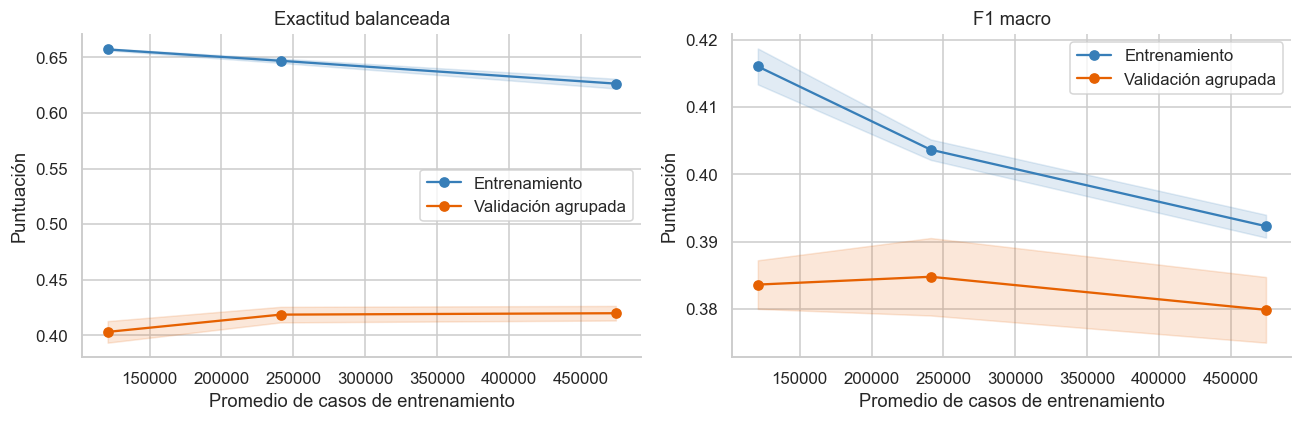

Entre 50 % y 100 % de establecimientos, la exactitud balanceada media de validación cambia **+0.0013**. Con todos los establecimientos disponibles, la brecha media entrenamiento–validación es **0.2067**. La curva permite valorar la tendencia dentro del rango observado; no demuestra que añadir filas de los mismos establecimientos tenga el mismo beneficio que incorporar establecimientos nuevos. Tampoco garantiza mejoras fuera de este periodo ni resuelve la escasez de fallecimientos.

In [22]:
learning_rows=[]
for r in evaluation['learning_curve']:
    learning_rows.append({'fraction':r['fraction'],'fold':r['fold'],'rows':r['train_rows'],'groups':r['train_groups'],
                         'train_balanced_accuracy':r['train_metrics']['balanced_accuracy'],
                         'validation_balanced_accuracy':r['validation_metrics']['balanced_accuracy'],
                         'train_macro_f1':r['train_metrics']['macro_f1'],
                         'validation_macro_f1':r['validation_metrics']['macro_f1']})
learning_table=pd.DataFrame(learning_rows)
display(learning_table.rename(columns={'fraction':'Fracción','fold':'Pliegue','rows':'Casos','groups':'Establecimientos',
    'train_balanced_accuracy':'Exactitud balanceada: entrenamiento','validation_balanced_accuracy':'Exactitud balanceada: validación',
    'train_macro_f1':'F1 macro: entrenamiento','validation_macro_f1':'F1 macro: validación'}))
learning_summary=learning_table.groupby('fraction').agg(['mean','std'])
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,metric,title in zip(axes,['balanced_accuracy','macro_f1'],['Exactitud balanceada','F1 macro']):
    x=learning_summary[('rows','mean')].to_numpy()
    for part,label,color in [('train','Entrenamiento','#377eb8'),('validation','Validación agrupada','#e66101')]:
        mean=learning_summary[(part+'_'+metric,'mean')].to_numpy()
        std=learning_summary[(part+'_'+metric,'std')].to_numpy()
        ax.plot(x,mean,'o-',label=label,color=color)
        ax.fill_between(x,mean-std,mean+std,alpha=.15,color=color)
    ax.set(title=title,xlabel='Promedio de casos de entrenamiento',ylabel='Puntuación')
    ax.legend()
plt.tight_layout();plt.show()
curve_delta=float(learning_summary.loc[1.0,('validation_balanced_accuracy','mean')]-learning_summary.loc[.5,('validation_balanced_accuracy','mean')])
curve_gap=float(learning_summary.loc[1.0,('train_balanced_accuracy','mean')]-learning_summary.loc[1.0,('validation_balanced_accuracy','mean')])
display(Markdown(f'Entre 50 % y 100 % de establecimientos, la exactitud balanceada media de validación cambia **{curve_delta:+.4f}**. '
                 f'Con todos los establecimientos disponibles, la brecha media entrenamiento–validación es **{curve_gap:.4f}**. '
                 'La curva permite valorar la tendencia dentro del rango observado; no demuestra que añadir filas de los mismos establecimientos tenga el mismo beneficio que incorporar establecimientos nuevos. '
                 'Tampoco garantiza mejoras fuera de este periodo ni resuelve la escasez de fallecimientos.'))


**Interpretación de la curva:** al pasar de 50 % a 100 % de establecimientos, la exactitud balanceada media de validación apenas aumenta 0,0013 y F1 macro disminuye aproximadamente 0,0049. No hay una mejora consistente entre los tres pliegues. La brecha media entrenamiento–validación en exactitud balanceada sigue siendo de alrededor de 0,207: es compatible con sobreajuste a patrones del entrenamiento, aunque esta métrica agregada no identifica por sí sola qué clase lo explica. Añadir más casos similares no parece, por sí solo, una solución suficiente. Incorporar establecimientos nuevos con mejor representación de Death y etiquetas más fiables podría ayudar; esto es una hipótesis, no una garantía derivada de la curva.

## 17. Evaluación final conservando la reserva original

Se evalúan una vez las especificaciones fijadas de antemano. La **exactitud balanceada** es la métrica principal y F1 macro es su complemento: cada clase contribuye por igual. Precisión, sensibilidad y F1 sin el calificativo macro se reportan con promedio **ponderado por soporte**, además de sus valores por clase. En clasificación multiclase de etiqueta única, la sensibilidad ponderada coincide con la exactitud; no es evidencia adicional.

ROC AUC se calcula mediante **uno contra el resto (OvR), promedio macro**, con probabilidades de las cuatro clases. La precisión promedio (AP) también se calcula por clase y con promedio macro. No se cambian umbrales: se usa la clase con mayor probabilidad. Los pesos balanceados afectan las probabilidades y no garantizan calibración.


,LogisticRegression,DummyClassifier
Exactitud,0.479735,0.366072
Precisión ponderada,0.533626,0.134009
Sensibilidad ponderada,0.479735,0.366072
F1 ponderado,0.496501,0.196196
F1 macro,0.374100,0.133987
Exactitud balanceada,0.419121,0.250000
ROC AUC macro (uno contra el resto),0.677973,0.500000
Precisión promedio macro (uno contra el resto),0.414653,0.250000
Brier multiclase (menor es mejor),0.634210,0.664480
Pérdida logarítmica (menor es mejor),1.104655,1.097888


,Modelo,Resultado,Precisión,Sensibilidad,F1,Casos
0,LogisticRegression,Fallecimiento (Death),0.001003,0.220588,0.001996,68
1,LogisticRegression,Días de ausencia,0.583211,0.362485,0.447089,65509
2,LogisticRegression,Traslado / restricción,0.466803,0.532171,0.497348,53045
3,LogisticRegression,Otro caso registrable,0.539139,0.561239,0.549967,60329
4,DummyClassifier,Fallecimiento (Death),0.000000,0.000000,0.000000,68
5,DummyClassifier,Días de ausencia,0.366072,1.000000,0.535949,65509
6,DummyClassifier,Traslado / restricción,0.000000,0.000000,0.000000,53045
7,DummyClassifier,Otro caso registrable,0.000000,0.000000,0.000000,60329


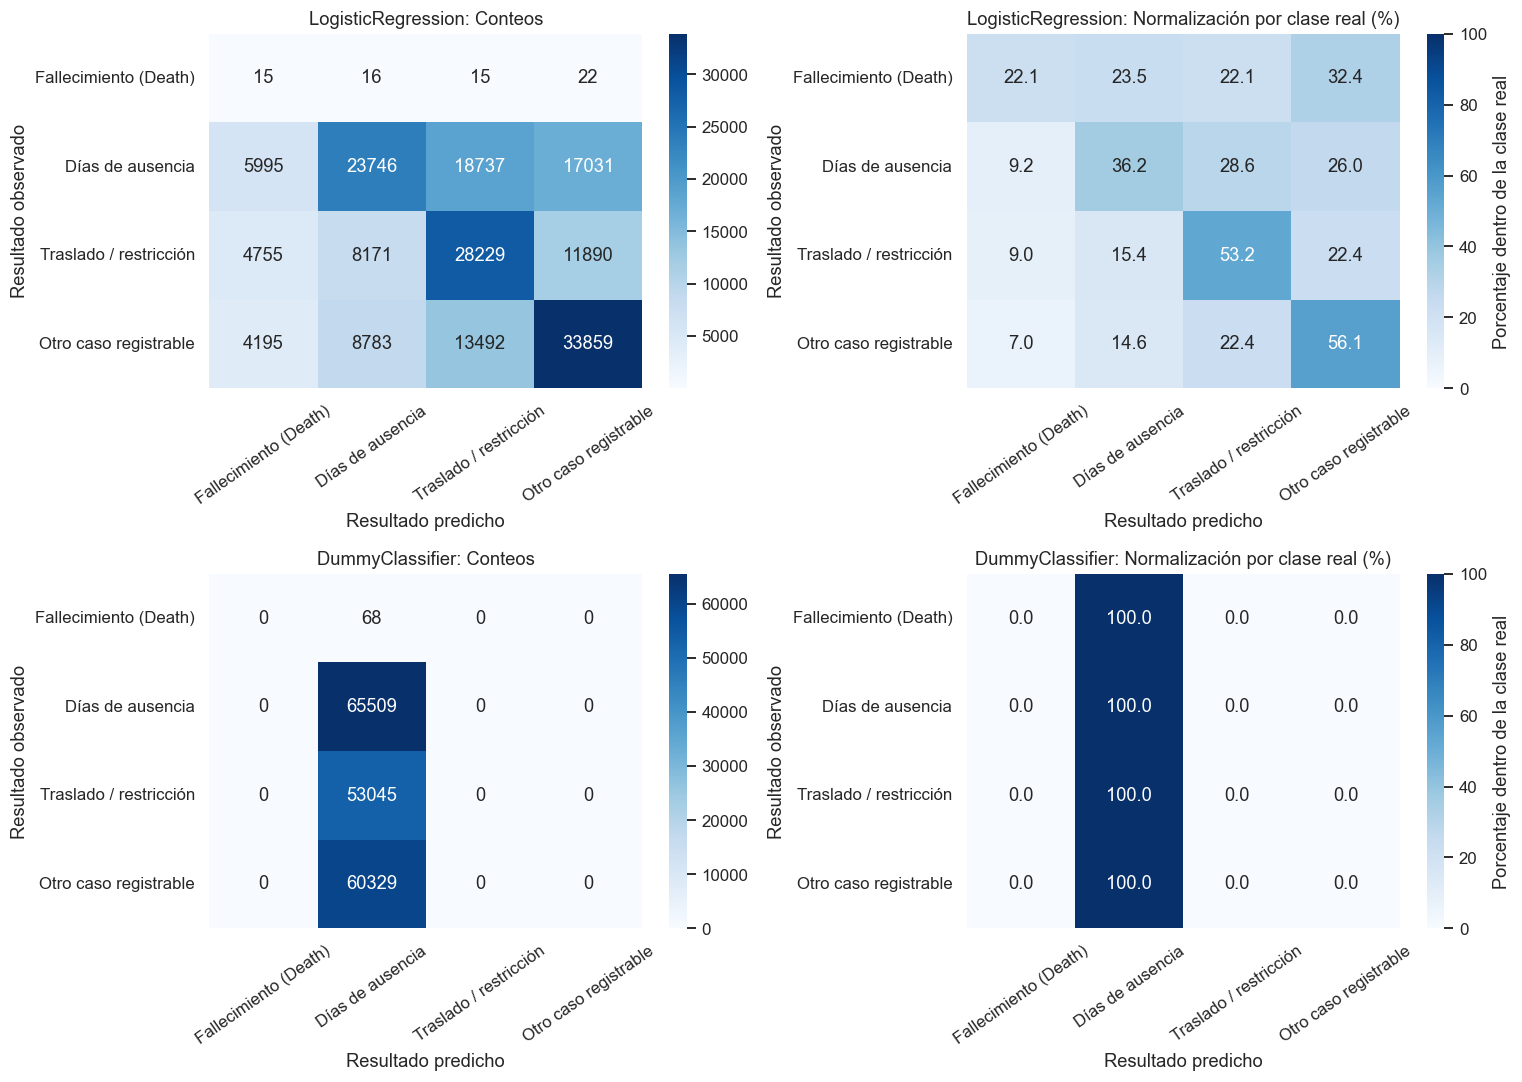

En la reserva hay **68 casos Death**, distribuidos en **68 establecimientos**. LogisticRegression obtiene precisión **0.100 %**, sensibilidad **22.06 %** y F1 **0.0020** para esta clase. La exactitud global no resume este comportamiento. No se elimina Death ni se agrupa con otra clase para mejorar las métricas.

In [23]:
predictions=np.load(CACHE_DIR/'holdout_predictions.npz',allow_pickle=False)
y_test=predictions['y']
probabilities={'LogisticRegression':predictions['lr'],'DummyClassifier':predictions['dummy']}
assert len(y_test)==baseline['test_rows'] and set(y_test)=={1,2,3,4}
scores=pd.DataFrame(evaluation['holdout_metrics']).rename(index=METRIC_LABELS)
display(scores)
reports=[]
for model,report in evaluation['classification_reports'].items():
    for label in [1,2,3,4]:
        r=report[str(label)]
        reports.append({'Modelo':model,'Resultado':OUTCOMES[label],'Precisión':r['precision'],
                        'Sensibilidad':r['recall'],'F1':r['f1-score'],'Casos':int(r['support'])})
display(pd.DataFrame(reports))
fig,axes=plt.subplots(2,2,figsize=(14,10))
for row,model in enumerate(probabilities):
    cm=np.array(evaluation['confusion_matrices'][model])
    labels=list(OUTCOMES.values())
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels,ax=axes[row,0])
    sns.heatmap(cm/cm.sum(axis=1,keepdims=True)*100,annot=True,fmt='.1f',vmin=0,vmax=100,cmap='Blues',
                xticklabels=labels,yticklabels=labels,ax=axes[row,1],cbar_kws={'label':'Porcentaje dentro de la clase real'})
    for col,title in enumerate(['Conteos','Normalización por clase real (%)']):
        axes[row,col].set(title=model+': '+title,xlabel='Resultado predicho',ylabel='Resultado observado')
        axes[row,col].tick_params(axis='x',rotation=35)
plt.tight_layout();plt.show()
death=evaluation['classification_reports']['LogisticRegression']['1']
display(Markdown(f'En la reserva hay **{int(death["support"])} casos Death**, distribuidos en '
                 f'**{evaluation["test_death_groups"]} establecimientos**. LogisticRegression obtiene precisión '
                 f'**{100*death["precision"]:.3f} %**, sensibilidad **{100*death["recall"]:.2f} %** y F1 **{death["f1-score"]:.4f}** para esta clase. '
                 'La exactitud global no resume este comportamiento. No se elimina Death ni se agrupa con otra clase para mejorar las métricas.'))


## 18. Curvas ROC y precisión–sensibilidad multiclase

Cada panel considera una clase positiva frente a las otras tres. Las curvas ROC pueden parecer favorables cuando hay muchos negativos; para Death debe prestarse especial atención a precisión–sensibilidad y AP. La referencia de AP sin información es la prevalencia de cada clase. AP es precisión promedio escalonada y no el área trapezoidal de la curva PR.

El panel PR de Death usa escala logarítmica en precisión para hacer visible su prevalencia muy baja; los puntos de precisión cero no son representables en esa escala. Los demás paneles conservan escala lineal.


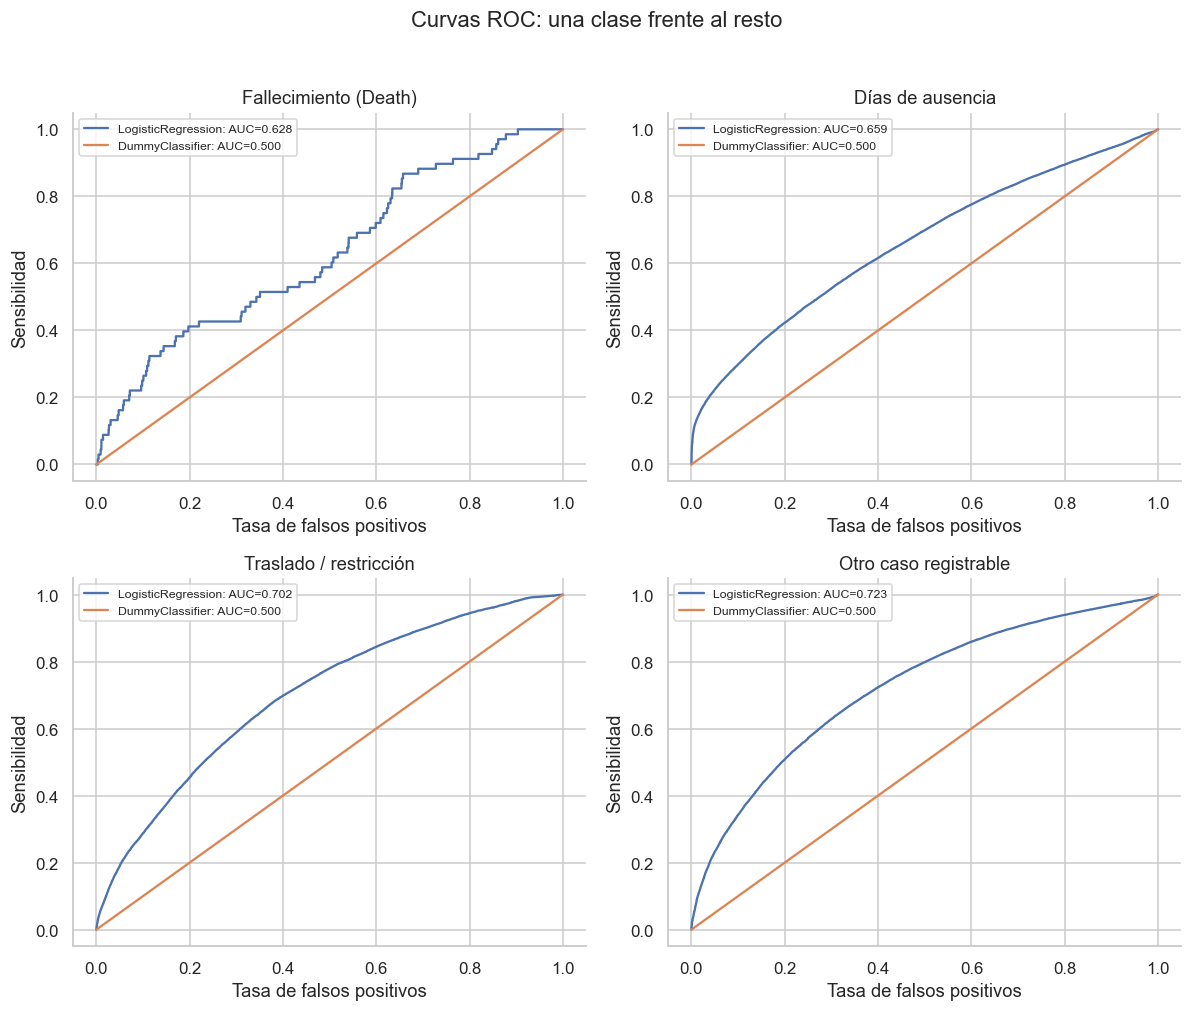

,Modelo,Resultado,ROC AUC OvR,AP OvR,Prevalencia
0,LogisticRegression,Fallecimiento (Death),0.628439,0.000830,0.000380
1,DummyClassifier,Fallecimiento (Death),0.500000,0.000380,0.000380
2,LogisticRegression,Días de ausencia,0.658974,0.579553,0.366072
3,DummyClassifier,Días de ausencia,0.500000,0.366072,0.366072
4,LogisticRegression,Traslado / restricción,0.701959,0.497211,0.296422
5,DummyClassifier,Traslado / restricción,0.500000,0.296422,0.296422
6,LogisticRegression,Otro caso registrable,0.722520,0.581020,0.337126
7,DummyClassifier,Otro caso registrable,0.500000,0.337126,0.337126


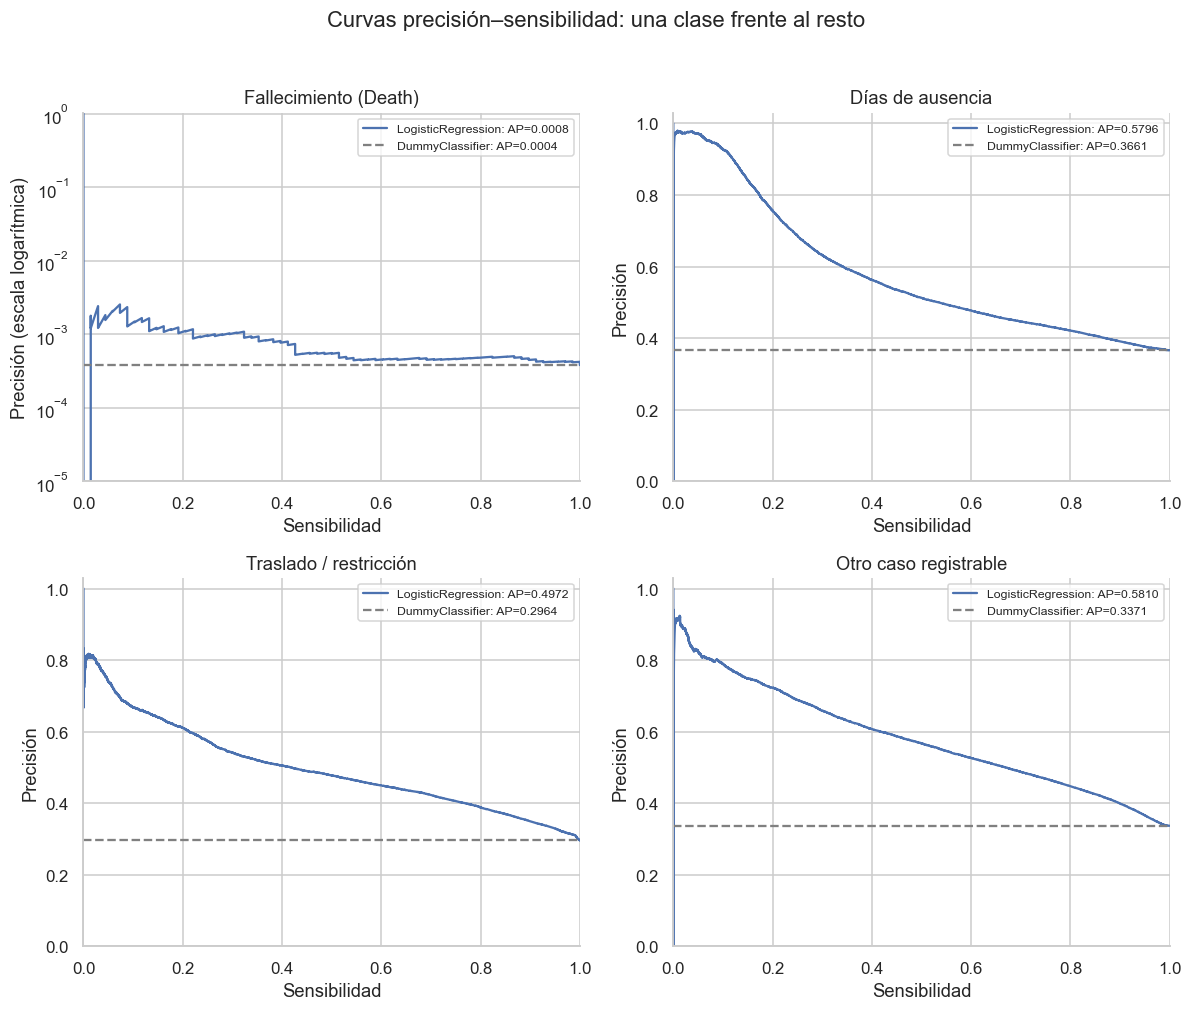

In [24]:
fig,axes=plt.subplots(2,2,figsize=(11,9))
ap_rows=[]
for k,ax in enumerate(axes.flat):
    label=k+1; binary=(y_test==label)
    for model,p in probabilities.items():
        fpr,tpr,_=roc_curve(binary,p[:,k])
        auc=roc_auc_score(binary,p[:,k])
        ax.plot(fpr,tpr,label=f'{model}: AUC={auc:.3f}')
        ap_rows.append({'Modelo':model,'Resultado':OUTCOMES[label],
                        'ROC AUC OvR':auc,'AP OvR':average_precision_score(binary,p[:,k]),
                        'Prevalencia':binary.mean()})
    ax.set(title=OUTCOMES[label],xlabel='Tasa de falsos positivos',ylabel='Sensibilidad')
    ax.legend(fontsize=8)
fig.suptitle('Curvas ROC: una clase frente al resto',y=1.02)
plt.tight_layout();plt.show()
display(pd.DataFrame(ap_rows))
fig,axes=plt.subplots(2,2,figsize=(11,9))
for k,ax in enumerate(axes.flat):
    binary=(y_test==k+1)
    precision,recall,_=precision_recall_curve(binary,probabilities['LogisticRegression'][:,k])
    ap=average_precision_score(binary,probabilities['LogisticRegression'][:,k])
    ax.plot(recall,precision,label=f'LogisticRegression: AP={ap:.4f}')
    ax.axhline(binary.mean(),linestyle='--',color='gray',label=f'DummyClassifier: AP={binary.mean():.4f}')
    ax.set(title=OUTCOMES[k+1],xlabel='Sensibilidad',ylabel='Precisión',xlim=(0,1),ylim=(0,1.03))
    if k==0:
        ax.set_yscale('log')
        ax.set_ylim(1e-5,1.03)
        ax.set_ylabel('Precisión (escala logarítmica)')
    ax.legend(fontsize=8)
fig.suptitle('Curvas precisión–sensibilidad: una clase frente al resto',y=1.02)
plt.tight_layout();plt.show()


## 19. Incertidumbre: bootstrap por establecimiento

Se remuestrean **establecimientos completos con reemplazo**, conservando todas sus filas y usando los mismos remuestreos para ambos modelos. Se calculan intervalos percentiles del 95 %: 1.000 réplicas para exactitud, exactitud balanceada y F1 macro; 200 para ROC AUC macro OvR por coste computacional. También se presentan intervalos de las diferencias pareadas LogisticRegression − DummyClassifier. Las réplicas sin alguna clase se descartan y su número se declara.

Estos intervalos son condicionales a los modelos ya ajustados y al conjunto de establecimientos observado; **no incluyen la variabilidad de volver a entrenar**, posibles vínculos entre empresas ni cambios de periodo. El pequeño número de fallecimientos limita especialmente la precisión de inferencias sobre Death. El remuestreo no se utiliza para seleccionar el modelo.


In [25]:
intervals=pd.DataFrame(evaluation['bootstrap']['intervals'])
intervals['point']=[evaluation['holdout_metrics'][r.model][r.metric] for r in intervals.itertuples()]
intervals['metric']=intervals.metric.map(METRIC_LABELS)
display(intervals[['model','metric','point','lower','upper','replicates']].rename(columns={
    'model':'Modelo','metric':'Métrica','point':'Estimación','lower':'Límite inferior 95 %','upper':'Límite superior 95 %','replicates':'Réplicas'}))
paired=pd.DataFrame(evaluation['bootstrap']['paired_differences'])
paired['point']=[evaluation['holdout_metrics']['LogisticRegression'][m]-evaluation['holdout_metrics']['DummyClassifier'][m] for m in paired.metric]
paired['metric']=paired.metric.map(METRIC_LABELS)
display(paired[['metric','point','lower','upper','replicates']].rename(columns={
    'metric':'Métrica','point':'Diferencia LR − Dummy','lower':'Límite inferior 95 %','upper':'Límite superior 95 %','replicates':'Réplicas'}))
print('Réplicas descartadas por ausencia de clase:',evaluation['bootstrap']['omitted_replicates'])
print('Semilla del bootstrap:',evaluation['bootstrap']['seed'])


,Modelo,Métrica,Estimación,Límite inferior 95 %,Límite superior 95 %,Réplicas
0,DummyClassifier,Exactitud,0.366072,0.356787,0.376046,1000
1,DummyClassifier,Exactitud balanceada,0.250000,0.250000,0.250000,1000
2,DummyClassifier,F1 macro,0.133987,0.131482,0.136640,1000
3,DummyClassifier,ROC AUC macro (uno contra el resto),0.500000,0.500000,0.500000,200
4,LogisticRegression,Exactitud,0.479735,0.471424,0.488134,1000
5,LogisticRegression,Exactitud balanceada,0.419121,0.393296,0.445911,1000
6,LogisticRegression,F1 macro,0.374100,0.367988,0.379980,1000
7,LogisticRegression,ROC AUC macro (uno contra el resto),0.677973,0.661357,0.695692,200


,Métrica,Diferencia LR − Dummy,Límite inferior 95 %,Límite superior 95 %,Réplicas
0,Exactitud,0.113662,0.099429,0.129162,1000
1,Exactitud balanceada,0.169121,0.143296,0.195911,1000
2,F1 macro,0.240113,0.232840,0.247460,1000
3,ROC AUC macro (uno contra el resto),0.177973,0.161357,0.195692,200


Réplicas descartadas por ausencia de clase: 0
Semilla del bootstrap: 142


## 20. Calibración: diagnóstico, sin reajustar probabilidades

Se inspeccionan curvas de confiabilidad OvR con hasta diez grupos de probabilidades por cuantiles. También se reportan Brier multiclase y pérdida logarítmica. Las probabilidades de la regresión con pesos de clase corresponden a un objetivo reponderado y pueden sobreestimar clases raras respecto de su frecuencia natural. Una discriminación superior no implica probabilidades bien calibradas. No se ajusta ningún calibrador con la reserva.

**Resultado observado:** Brier multiclase mejora frente a DummyClassifier (0,6342 frente a 0,6645), pero la pérdida logarítmica empeora ligeramente (1,1047 frente a 1,0979). Por tanto, el avance en discriminación no equivale a una mejora uniforme de la calidad probabilística. La ponderación de clases y la rareza de Death exigen especial cautela al interpretar probabilidades.


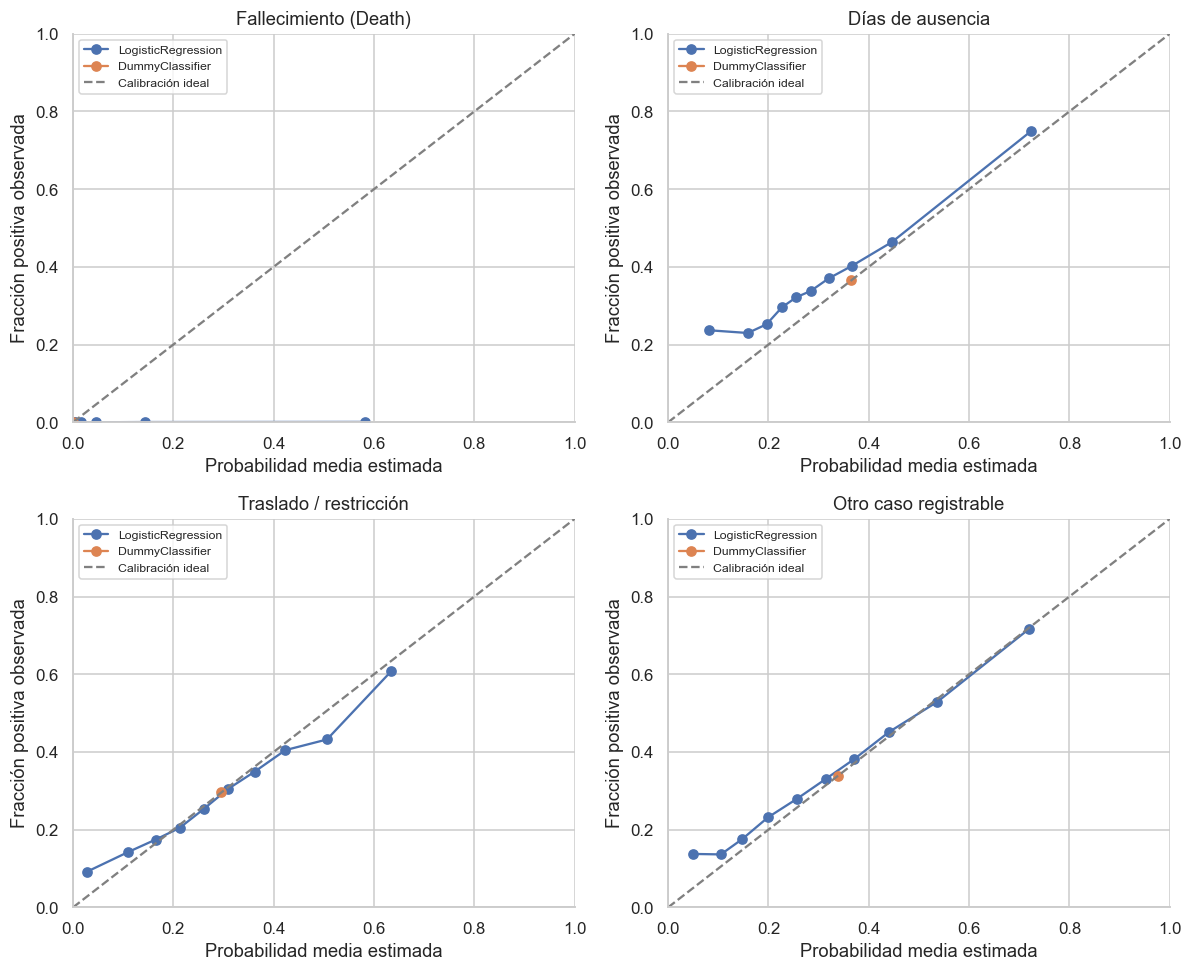

,LogisticRegression,DummyClassifier
Brier multiclase (menor es mejor),0.634210,0.664480
Pérdida logarítmica (menor es mejor),1.104655,1.097888


In [26]:
fig,axes=plt.subplots(2,2,figsize=(11,9))
for k,ax in enumerate(axes.flat):
    for model,p in probabilities.items():
        observed,estimated=calibration_curve(y_test==k+1,p[:,k],n_bins=10,strategy='quantile')
        ax.plot(estimated,observed,'o-',label=model)
    ax.plot([0,1],[0,1],'--',color='gray',label='Calibración ideal')
    ax.set(title=OUTCOMES[k+1],xlabel='Probabilidad media estimada',ylabel='Fracción positiva observada',xlim=(0,1),ylim=(0,1))
    ax.legend(fontsize=8)
plt.tight_layout();plt.show()
display(scores.loc[[METRIC_LABELS['brier_multiclass'],METRIC_LABELS['log_loss']]])


## 21. Interpretación de coeficientes multinomiales

Se interpretan **contrastes entre categorías de un mismo predictor**, manteniendo los demás fijos. Para la clase k frente a «Otro caso registrable», el cambio de logaritmo de posibilidades al pasar de la categoría b a la a es:

`(beta[k,a] - beta[4,a]) - (beta[k,b] - beta[4,b])`.

Su exponencial es una razón de posibilidades relativa dentro del modelo. Esta comparación evita interpretar un indicador one-hot aislado como si las demás categorías del mismo predictor pudieran permanecer invariables. Se conserva la regularización y la ponderación balanceada; no se presentan intervalos inferenciales de los coeficientes. Las asociaciones **no son efectos causales**, pueden reflejar confusión y prácticas de reporte, y los coeficientes de Death son especialmente inestables. No se realiza selección de variables a partir de esta tabla.

**Ejemplo observado:** la afección respiratoria frente a lesión se asocia en el modelo con una razón de posibilidades relativa de aproximadamente 17,94 para días de ausencia frente a otro caso registrable, manteniendo los demás predictores fijos. Se trata de un contraste del modelo reponderado, no de una tasa poblacional ni de un efecto causal. Los contrastes extremos de Death deben leerse como estimaciones regularizadas con muy pocos eventos, no como efectos precisos.


In [27]:
final_model=joblib.load(CACHE_DIR/'final_lr.joblib')['model']
coefficient=pd.read_csv(CACHE_DIR/'coefficients.csv',index_col=0)
coefficient.columns=coefficient.columns.astype(int)
contrasts=[('type_of_incident','3','1','Afección respiratoria frente a lesión'),
           ('type_of_incident','5','1','Pérdida auditiva frente a lesión'),
           ('soc_code','29-1141','53-7062','Enfermería profesional frente a movimiento manual de materiales'),
           ('naics_code','622110','493110','Hospitales generales frente a almacenamiento general')]
rows=[]
for field,a,b,label in contrasts:
    ca,cb=f'{field}_{a}',f'{field}_{b}'
    if ca not in coefficient.index or cb not in coefficient.index:
        print('Contraste no disponible en la codificación:',field,a,b);continue
    for k in [1,2,3]:
        delta=float((coefficient.loc[ca,k]-coefficient.loc[ca,4])-(coefficient.loc[cb,k]-coefficient.loc[cb,4]))
        rows.append({'Predictor':field,'Comparación':label,'Clase frente a otro caso registrable':OUTCOMES[k],
                     'Cambio en logaritmo de posibilidades':delta,'Razón de posibilidades relativa':np.exp(delta)})
display(pd.DataFrame(rows))


,Predictor,Comparación,Clase frente a otro caso registrable,Cambio en logaritmo de posibilidades,Razón de posibilidades relativa
0,type_of_incident,Afección respiratoria frente a lesión,Fallecimiento (Death),3.567612,35.431888
1,type_of_incident,Afección respiratoria frente a lesión,Días de ausencia,2.887204,17.943069
2,type_of_incident,Afección respiratoria frente a lesión,Traslado / restricción,-1.245790,0.287713
3,type_of_incident,Pérdida auditiva frente a lesión,Fallecimiento (Death),-0.587530,0.555698
4,type_of_incident,Pérdida auditiva frente a lesión,Días de ausencia,-1.849739,0.157278
5,type_of_incident,Pérdida auditiva frente a lesión,Traslado / restricción,-1.779329,0.168751
6,soc_code,Enfermería profesional frente a movimiento man...,Fallecimiento (Death),-6.837549,0.001073
7,soc_code,Enfermería profesional frente a movimiento man...,Días de ausencia,-0.829249,0.436377
8,soc_code,Enfermería profesional frente a movimiento man...,Traslado / restricción,-0.719327,0.487080
9,naics_code,Hospitales generales frente a almacenamiento g...,Fallecimiento (Death),-2.176306,0.113460


## 22. Conclusiones y límites de la evaluación

El problema conserva su interpretación: clasificar el resultado final de casos ya reportados usando información estructurada, sin reconstruir el desenlace mediante días de recuperación o fecha de fallecimiento. Se mantiene Death por su importancia sustantiva, aun cuando su rareza dificulta estimación y evaluación. Una formulación alternativa de interés operativo podría estudiarse en trabajo futuro, con justificación previa y una evaluación nueva; no se utiliza para mejorar estos resultados.

La agrupación por establecimiento reduce la fuga por identidad y la dependencia más evidente, pero no elimina relaciones entre empresas, trabajadores no identificados o prácticas de reporte compartidas. La población observada responde a requisitos administrativos, no a una muestra representativa de todos los trabajadores. **Los conteos de casos no permiten estimar tasas de lesiones** sin denominadores de exposición apropiados.

Las inconsistencias de días y etiquetas, los totales anuales anómalos y la falta de información ocupacional/horaria limitan la validez. Los códigos de ocupación y ciertos atributos del incidente se registran retrospectivamente: su disponibilidad en el uso propuesto debe verificarse. La clasificación evaluada no demuestra anticipación clínica del desenlace.

Los identificadores y ubicaciones detalladas se excluyen de predicción. La publicación de combinaciones de ocupación, fecha y establecimiento puede favorecer reidentificación; el Jupyter Book debe evitar ejemplos individuales y no redistribuir datos sin verificar las condiciones de uso. Las métricas agregadas no establecen equidad ni justifican decisiones sobre trabajadores.


In [28]:
lr=evaluation['holdout_metrics']['LogisticRegression']; dummy=evaluation['holdout_metrics']['DummyClassifier']
display(Markdown(f'**Resultado del ajuste corregido:** exactitud balanceada **{lr["balanced_accuracy"]:.4f}** frente a **{dummy["balanced_accuracy"]:.4f}** de DummyClassifier; '
                 f'F1 macro **{lr["macro_f1"]:.4f}** frente a **{dummy["macro_f1"]:.4f}**; '
                 f'ROC AUC macro OvR **{lr["roc_auc_macro_ovr"]:.4f}** frente a **{dummy["roc_auc_macro_ovr"]:.4f}**. '
                 f'La exactitud es **{100*lr["accuracy"]:.2f} %** frente a **{100*dummy["accuracy"]:.2f} %**. '
                 f'El ajuste convergió en **{evaluation["final_fit"]["iterations"][0]} iteraciones**, sin seleccionar parámetros por estos resultados. '
                 'La comparación debe leerse junto con los intervalos agrupados, la validación interna, las métricas de Death y el diagnóstico de calibración.'))


**Resultado del ajuste corregido:** exactitud balanceada **0.4191** frente a **0.2500** de DummyClassifier; F1 macro **0.3741** frente a **0.1340**; ROC AUC macro OvR **0.6780** frente a **0.5000**. La exactitud es **47.97 %** frente a **36.61 %**. El ajuste convergió en **30 iteraciones**, sin seleccionar parámetros por estos resultados. La comparación debe leerse junto con los intervalos agrupados, la validación interna, las métricas de Death y el diagnóstico de calibración.

## 23. Reproducibilidad, alcance y pendientes

- **Entorno:** Python del entorno existente `ml_env`; no se instala ni modifica ningún paquete. Las versiones ejecutadas se muestran a continuación. `requirements.txt` documenta las dependencias directas; debe acompañar el Jupyter Book junto con el notebook y `osha_deliverable_utils.py`. Alternativamente puede suministrarse un `environment.yml` completo generado desde el entorno autorizado.
- **Semillas:** 42 para modelos y pliegues; 43, 44 y 45 para los órdenes anidados de establecimientos de cada pliegue; 142 para bootstrap. Las pertenencias de la reserva se leen del resultado original y no se sortean de nuevo.
- **Archivos de entrada:** CSV local, `../osha_screening_results.json` y `../promotion/eda_utils.py`. Para publicar el libro hay que conservar estas rutas relativas o documentar su ajuste. No basta con distribuir el notebook aislado. Las cachés de `osha_deliverable_results` son opcionales: en su ausencia se recalculan los ajustes y la evaluación mediante la misma especificación. Las cachés contienen predicciones y modelos, no sustituyen los datos de entrada.
- **Integridad del análisis:** los datos originales, la variable objetivo y los establecimientos de entrenamiento/evaluación permanecen sin modificaciones. No se prueban familias adicionales de modelos ni se realiza búsqueda de hiperparámetros.

**Pendientes explícitos:** construir y verificar la publicación en Jupyter Book y confirmar formalmente las condiciones de redistribución del archivo original. El análisis temporal agregado no equivale a una validación prospectiva entre años; con un solo año, la generalización a periodos futuros permanece fuera del alcance. La clasificación MCAR/MAR/MNAR no puede establecerse de forma definitiva con este archivo, y los posibles vínculos entre empresas o trabajadores no identificados permanecen como limitaciones.

Para cambiar posteriormente el preprocesamiento del módulo, debe invalidarse explícitamente la caché incrementando `design_version`; no deben reutilizarse ajustes de una especificación diferente. Antes de publicar también debe revisarse la vista previa de casos individuales para evitar exponer identificadores innecesarios.


In [29]:
from importlib.metadata import version
package_names=['numpy','pandas','scipy','scikit-learn','matplotlib','seaborn','joblib','threadpoolctl','ipython','ipykernel','jupyter-client']
versions=pd.DataFrame({'Paquete':package_names,'Versión':[version(name) for name in package_names]})
display(versions)
print('Python:',sys.version.split()[0])
assert (DATA_PATH.stat().st_size,DATA_PATH.stat().st_mtime_ns)==raw_signature
assert hashlib.sha256(UTILS_PATH.read_bytes()).hexdigest()==utils_hash
assert evaluation['features']==baseline['features']
assert evaluation['final_fit']['converged'] and all(r['converged'] for r in evaluation['learning_curve'])
assert len(plt.get_fignums())==0
print('Verificación final: datos y utilidades originales sin cambios; partición y predictores conservados.')


,Paquete,Versión
0,numpy,1.23.5
1,pandas,1.5.3
2,scipy,1.10.1
3,scikit-learn,1.2.2
4,matplotlib,3.7.5
5,seaborn,0.12.2
6,joblib,1.5.3
7,threadpoolctl,3.7.0
8,ipython,8.18.1
9,ipykernel,6.30.1


Python: 3.9.25
Verificación final: datos y utilidades originales sin cambios; partición y predictores conservados.
